In [ ]:
from pathlib import Path
import re
from datetime import datetime
from typing import Callable, Iterable, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import rankdata

from HPC_2P_analysis.utils.config import (
    get_itr_index,
    index_to_type,
    select_files,
)
from HPC_2P_analysis.utils.loadData import (
    load_screen_data,
)


CorrMethod = Literal["pearson", "spearman"]
GroupAverage = Literal["by_condition", "by_trial"]
SimilarityMode = Literal["interval", "curve"]
ValueType = Literal["standardized_beta", "raw_beta", "template_corr"]
PAdjustMethod = Literal["none", "bonferroni", "holm", "fdr_bh"]

In [159]:
RULE_LABEL_MAP = {
    "AB_s1e1": "A1",
    "BA_s2e2": "A2",
    "BA_s1e1": "B1",
    "AB_s2e2": "B2",
}


def display_rule_labels(labels: list[str]) -> list[str]:
    return [RULE_LABEL_MAP.get(label, "?") for label in labels]


def upper_tri_offdiag(mat: np.ndarray) -> np.ndarray:
    idx = np.triu_indices_from(mat, k=1)
    return mat[idx]


def zscore_1d(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / (np.nanstd(x) + eps)


def make_pure_pattern_position_matrices(
    display_labels: list[str],
) -> tuple[np.ndarray, np.ndarray]:
    """
    display_labels usually:
        ["A1", "A2", "B1", "B2"]

    pattern:
        A vs B

    position:
        1 vs 2
    """
    patterns = [label[0] for label in display_labels]
    positions = [label[1:] for label in display_labels]

    pure_pattern = np.equal.outer(patterns, patterns).astype(float)
    pure_position = np.equal.outer(positions, positions).astype(float)

    return pure_pattern, pure_position


def corr_matrix_from_vectors(
    vectors: list[np.ndarray],
    *,
    method: CorrMethod = "spearman",
    min_neurons: int = 3,
) -> np.ndarray:
    """
    vectors:
        list of four population vectors.

    Returns:
        4 x 4 correlation matrix.
    """
    x = np.stack(vectors, axis=0).astype(float)

    valid = np.all(np.isfinite(x), axis=0)
    x = x[:, valid]

    if x.shape[1] < min_neurons:
        return np.full((len(vectors), len(vectors)), np.nan)

    if np.any(np.nanstd(x, axis=1) < 1e-12):
        return np.full((len(vectors), len(vectors)), np.nan)

    if method == "pearson":
        return np.corrcoef(x)

    if method == "spearman":
        x_rank = np.stack([rankdata(row) for row in x], axis=0)
        return np.corrcoef(x_rank)

    raise ValueError("method must be 'pearson' or 'spearman'")


def compute_pattern_position_value_from_corr(
    corr: np.ndarray,
    labels: list[str],
    *,
    value_type: ValueType = "raw_beta",
    fit_intercept: bool = True,
) -> dict:
    """
    From one 4 x 4 correlation matrix, compute:
        pattern_value
        position_value
    """
    display_labels = display_rule_labels(labels)

    pure_pattern, pure_position = make_pure_pattern_position_matrices(
        display_labels
    )

    y = upper_tri_offdiag(corr)
    x_pattern = upper_tri_offdiag(pure_pattern)
    x_position = upper_tri_offdiag(pure_position)

    valid = (
        np.isfinite(y)
        & np.isfinite(x_pattern)
        & np.isfinite(x_position)
    )

    y = y[valid]
    x_pattern = x_pattern[valid]
    x_position = x_position[valid]

    if len(y) < 3:
        return {
            "labels": display_labels,
            "value_type": value_type,
            "pattern_value": np.nan,
            "position_value": np.nan,
            "intercept": np.nan,
            "pure_pattern": pure_pattern,
            "pure_position": pure_position,
            "observed_offdiag": y,
            "pattern_template_offdiag": x_pattern,
            "position_template_offdiag": x_position,
        }

    if value_type == "raw_beta":
        y_fit = y
        xp_fit = x_pattern
        xq_fit = x_position

    elif value_type == "standardized_beta":
        y_fit = zscore_1d(y)
        xp_fit = zscore_1d(x_pattern)
        xq_fit = zscore_1d(x_position)

    elif value_type == "template_corr":
        pattern_value = float(np.corrcoef(y, x_pattern)[0, 1])
        position_value = float(np.corrcoef(y, x_position)[0, 1])

        return {
            "labels": display_labels,
            "value_type": value_type,
            "pattern_value": pattern_value,
            "position_value": position_value,
            "intercept": np.nan,
            "pure_pattern": pure_pattern,
            "pure_position": pure_position,
            "observed_offdiag": y,
            "pattern_template_offdiag": x_pattern,
            "position_template_offdiag": x_position,
        }

    else:
        raise ValueError(
            "value_type must be 'standardized_beta', "
            "'raw_beta', or 'template_corr'"
        )

    design = np.column_stack([xp_fit, xq_fit])

    if fit_intercept:
        design = np.column_stack([np.ones(len(y_fit)), design])

    beta = np.linalg.lstsq(design, y_fit, rcond=None)[0]

    if fit_intercept:
        intercept = float(beta[0])
        pattern_value = float(beta[1])
        position_value = float(beta[2])
    else:
        intercept = 0.0
        pattern_value = float(beta[0])
        position_value = float(beta[1])

    return {
        "labels": display_labels,
        "value_type": value_type,
        "pattern_value": pattern_value,
        "position_value": position_value,
        "intercept": intercept,
        "pure_pattern": pure_pattern,
        "pure_position": pure_position,
        "observed_offdiag": y,
        "pattern_template_offdiag": x_pattern,
        "position_template_offdiag": x_position,
    }

In [187]:
def plot_similarity_matrix(
    matrix: np.ndarray,
    labels: Iterable[str],
    *,
    title: str,
    value_label: str = "correlation",
    figsize: tuple[float, float] = (5.3, 4.8),
    cmap: str = "coolwarm",
    vmin: float | None = -1,
    vmax: float | None = 1,
    annotate: bool = True,
    annotation_format: str = ".2f",
):
    """
    Plot one square similarity/template matrix.
    """
    matrix = np.asarray(matrix, dtype=float)
    labels = list(labels)

    if matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]:
        raise ValueError(
            f"matrix must be square, got shape {matrix.shape}."
        )

    if matrix.shape[0] != len(labels):
        raise ValueError(
            f"Number of labels ({len(labels)}) does not match "
            f"matrix shape {matrix.shape}."
        )

    fig, ax = plt.subplots(figsize=figsize)

    image = ax.imshow(
        matrix,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    indices = np.arange(len(labels))

    ax.set_xticks(indices)
    ax.set_yticks(indices)
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    if annotate:
        for row in range(matrix.shape[0]):
            for col in range(matrix.shape[1]):
                value = matrix[row, col]

                text = (
                    "NaN"
                    if not np.isfinite(value)
                    else format(value, annotation_format)
                )

                ax.text(
                    col,
                    row,
                    text,
                    ha="center",
                    va="center",
                    fontsize=11,
                )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )
    colorbar.set_label(value_label)

    ax.set_title(title, fontsize=15, pad=12)

    fig.tight_layout()
    plt.show()

    return fig, ax


def plot_pattern_position_templates(
    labels: Iterable[str] = ("A1", "A2", "B1", "B2"),
):
    """
    Plot pure-pattern and pure-position template matrices.
    """
    labels = list(labels)

    pure_pattern, pure_position = (
        make_pure_pattern_position_matrices(labels)
    )

    plot_similarity_matrix(
        pure_pattern,
        labels,
        title="Pure pattern template",
        value_label="template value",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        annotation_format=".0f",
    )

    plot_similarity_matrix(
        pure_position,
        labels,
        title="Pure position template",
        value_label="template value",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        annotation_format=".0f",
    )

    return {
        "pure_pattern": pure_pattern,
        "pure_position": pure_position,
    }
    
    
def inspect_single_file_similarity(
    file_path,
    *,
    ana_tt: Iterable[str],
    ana_bt: Iterable[str] = ("Correct",),
    group_average: GroupAverage = "by_trial",
    corr_method: CorrMethod = "spearman",
    value_type: ValueType = "raw_beta",
    screen_mode: str = "masked",
    plot_templates: bool = False,
    matrix_title: str | None = None,
) -> dict:
    """
    Compute and visualize interval similarity for one file.

    This function always uses mode="interval", because interval analysis
    produces one 4 x 4 correlation matrix for the file.

    It:
        1. loads one raw/screen file;
        2. extracts A1/A2/B1/B2 population vectors;
        3. computes the correlation matrix;
        4. computes pattern and position similarity;
        5. prints the result;
        6. plots the observed correlation matrix;
        7. optionally plots pure pattern and position templates.
    """
    file_path = Path(file_path)

    result = compute_similarity(
        file_path,
        ana_tt=ana_tt,
        ana_bt=ana_bt,
        mode="interval",
        group_average=group_average,
        corr_method=corr_method,
        value_type=value_type,
        screen_mode=screen_mode,
    )

    corr = result["corr"]
    values = result["values"]
    labels = values["labels"]
    intervals = result["intervals"]
    meta = result["meta"]

    task_type = meta.get("task_type", "unknown")
    reward_mode = meta.get("reward_mode", "unknown")
    mouse_id = meta.get("mouse_id", "unknown")

    if matrix_title is None:
        matrix_title = (
            f"{mouse_id} | {task_type} | {reward_mode}\n"
            f"{corr_method.capitalize()} correlation matrix"
        )

    print("=" * 70)
    print(f"File:          {file_path}")
    print(f"Mouse:         {mouse_id}")
    print(f"Task type:     {task_type}")
    print(f"Reward mode:   {reward_mode}")
    print(f"Screen mode:   {screen_mode}")
    print(f"Track types:   {tuple(ana_tt)}")
    print(f"Behavior:      {tuple(ana_bt)}")
    print(f"Group average: {group_average}")
    print(f"Correlation:   {corr_method}")
    print(f"Value type:    {value_type}")

    print(
        "Intervals:     "
        f"zone 1=[{intervals['s1']}, {intervals['e1']}), "
        f"zone 2=[{intervals['s2']}, {intervals['e2']})"
    )

    print("-" * 70)
    print(f"Pattern similarity:  {values['pattern_value']:.6f}")
    print(f"Position similarity: {values['position_value']:.6f}")

    if np.isfinite(values["intercept"]):
        print(f"Intercept:           {values['intercept']:.6f}")

    # For raw_beta, print the three directly interpretable means.
    if value_type == "raw_beta":
        y = np.asarray(values["observed_offdiag"], dtype=float)
        pattern_template = np.asarray(
            values["pattern_template_offdiag"],
            dtype=float,
        )
        position_template = np.asarray(
            values["position_template_offdiag"],
            dtype=float,
        )

        same_pattern_mask = (
            (pattern_template == 1)
            & (position_template == 0)
        )
        same_position_mask = (
            (pattern_template == 0)
            & (position_template == 1)
        )
        neither_mask = (
            (pattern_template == 0)
            & (position_template == 0)
        )

        mean_same_pattern = float(
            np.nanmean(y[same_pattern_mask])
        )
        mean_same_position = float(
            np.nanmean(y[same_position_mask])
        )
        mean_neither = float(
            np.nanmean(y[neither_mask])
        )

        print("-" * 70)
        print(f"Mean same-pattern correlation:  {mean_same_pattern:.6f}")
        print(f"Mean same-position correlation: {mean_same_position:.6f}")
        print(f"Mean neither correlation:       {mean_neither:.6f}")

        print(
            "Pattern contrast check:        "
            f"{mean_same_pattern - mean_neither:.6f}"
        )
        print(
            "Position contrast check:       "
            f"{mean_same_position - mean_neither:.6f}"
        )

    print("=" * 70)

    plot_similarity_matrix(
        corr,
        labels,
        title=matrix_title,
        value_label=f"{corr_method} correlation",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        annotation_format=".2f",
    )

    if plot_templates:
        plot_pattern_position_templates(labels)

    return result

File:          ../../../data/HPC_2p/screen/HP01/HP01_2024-12-24_position_screen.pkl
Mouse:         HP01
Task type:     position
Reward mode:   full
Screen mode:   masked
Track types:   ('ABC', 'ACB', 'BAC', 'BCA', 'CAB', 'CBA')
Behavior:      ('Correct',)
Group average: by_trial
Correlation:   spearman
Value type:    raw_beta
Intervals:     zone 1=[48, 61), zone 2=[108, 121)
----------------------------------------------------------------------
Pattern similarity:  0.343713
Position similarity: 0.389673
Intercept:           -0.073112
----------------------------------------------------------------------
Mean same-pattern correlation:  0.270601
Mean same-position correlation: 0.316561
Mean neither correlation:       -0.073112
Pattern contrast check:        0.343713
Position contrast check:       0.389673


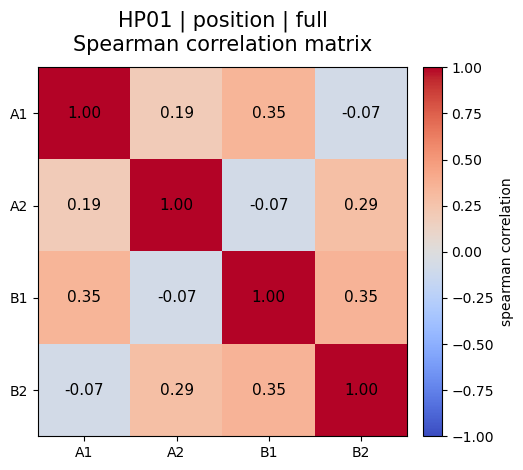

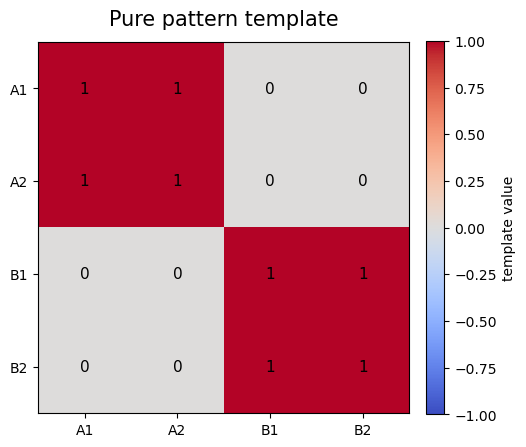

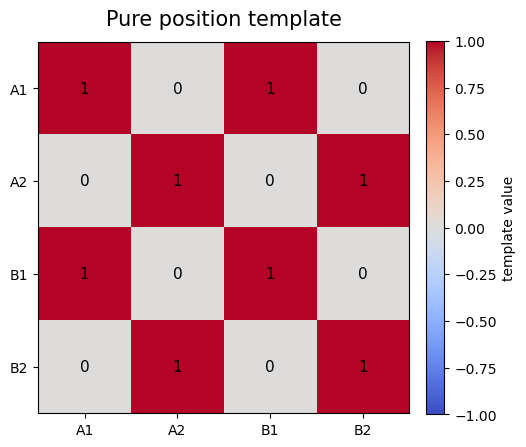

In [188]:
file_path = "../../../data/HPC_2p/screen/HP01/HP01_2024-12-24_position_screen.pkl"

single_result = inspect_single_file_similarity(
    file_path,
    ana_tt=("ABC", "ACB", "BAC", "BCA", "CAB", "CBA"),
    ana_bt=("Correct",),
    group_average="by_trial",
    corr_method="spearman",
    value_type="raw_beta",
    screen_mode="masked",
    plot_templates=True,
)

In [ ]:
def get_zone_bounds(
    zones,
    *,
    n_position: int,
    mode: SimilarityMode,
) -> tuple[int, int, int, int]:
    """
    Get two analysis intervals from reward-zone information.

    Returned intervals use Python half-open indexing:
        [s1, e1), [s2, e2)

    mode="curve"
    ------------
    Use the larger intervals between adjacent reward zones:

        interval 1:
            end of zones[0] -> start of zones[2]

        interval 2:
            end of zones[2] -> start of zones[4]

    mode="interval"
    ---------------
    Use the smaller reward-zone intervals:

        interval 1 = zones[1]
        interval 2 = zones[3]
    """
    def first_number(x) -> float:
        values = np.asarray(x).ravel()

        if len(values) < 2:
            raise ValueError(
                f"Each zone must contain at least two bounds, got {values}."
            )

        return float(values[0])

    def second_number(x) -> float:
        values = np.asarray(x).ravel()

        if len(values) < 2:
            raise ValueError(
                f"Each zone must contain at least two bounds, got {values}."
            )

        return float(values[1])

    if mode == "curve":
        # Larger intervals.
        s1 = int(np.floor(second_number(zones[0])))
        e1 = int(np.ceil(first_number(zones[2])))

        s2 = int(np.floor(second_number(zones[2])))
        e2 = int(np.ceil(first_number(zones[4])))

    elif mode == "interval":
        # Smaller reward-zone intervals.
        s1 = int(np.floor(first_number(zones[1])))
        e1 = int(np.ceil(second_number(zones[1])))

        s2 = int(np.floor(first_number(zones[3])))
        e2 = int(np.ceil(second_number(zones[3])))

    else:
        raise ValueError(
            "mode must be 'curve' or 'interval', "
            f"got {mode!r}."
        )

    # Clamp to valid Python indexing range.
    s1 = int(np.clip(s1, 0, n_position))
    e1 = int(np.clip(e1, 0, n_position))
    s2 = int(np.clip(s2, 0, n_position))
    e2 = int(np.clip(e2, 0, n_position))

    if e1 <= s1:
        raise ValueError(
            f"Invalid zone 1 interval for mode={mode!r}: "
            f"[{s1}, {e1})."
        )

    if e2 <= s2:
        raise ValueError(
            f"Invalid zone 2 interval for mode={mode!r}: "
            f"[{s2}, {e2})."
        )

    return s1, e1, s2, e2


def get_track_direction(track_name: str) -> str:
    """
    CAB / ACB / ABC -> AB
    CBA / BCA / BAC -> BA

    couple_ACB / couple_BCA will first remove "couple_".
    """
    base = track_name.replace("couple_", "")

    if base in {"CAB", "ACB", "ABC"}:
        return "AB"

    if base in {"CBA", "BCA", "BAC"}:
        return "BA"

    raise ValueError(f"Trial type not recognized: {track_name}")


def aggregate_label_arrays(
    group_data: dict[str, list[np.ndarray]],
    *,
    labels: list[str],
    group_average: GroupAverage = "by_trial",
) -> dict[str, np.ndarray]:
    """
    Aggregate arrays from multiple trial types.

    interval mode:
        each array shape = (n_neuron, n_trial)

    curve mode:
        each array shape = (n_neuron, n_trial, n_local_position)

    by_trial:
        concatenate trials first, then average trials.

    by_condition:
        average trials within each condition first, then average conditions.
    """
    out = {}

    for label in labels:
        arrays = group_data[label]

        if len(arrays) == 0:
            raise ValueError(f"No data collected for label={label!r}")

        if group_average == "by_trial":
            all_trials = np.concatenate(arrays, axis=1)
            out[label] = np.nanmean(all_trials, axis=1)

        elif group_average == "by_condition":
            condition_means = [
                np.nanmean(arr, axis=1)
                for arr in arrays
            ]

            out[label] = np.nanmean(
                np.stack(condition_means, axis=0),
                axis=0,
            )

        else:
            raise ValueError(
                "group_average must be 'by_trial' or 'by_condition'"
            )

    return out


def collect_similarity_vectors(
    file_path,
    *,
    ana_tt: Iterable[str],
    ana_bt: Iterable[str] = ("Correct",),
    mode: SimilarityMode = "interval",
    group_average: GroupAverage = "by_trial",
    screen_mode: str = "masked",
) -> dict:
    """
    Core data extraction.

    interval mode:
        1. slice zone interval
        2. average neural activity within interval
        3. aggregate trials / conditions
        4. later compute population similarity

    curve mode:
        keep each relative position in the two intervals.
    """
    file_path = Path(file_path)

    data = load_screen_data(
        file_path,
        screen_mode=screen_mode,
    )

    labels = [
        "AB_s1e1",
        "BA_s2e2",
        "BA_s1e1",
        "AB_s2e2",
    ]

    group_data = {label: [] for label in labels}

    n_position = None

    for tt_idx, bt_idx in get_itr_index(data, ana_tt, ana_bt):
        fr = data["firing"][tt_idx, bt_idx]

        if fr is not None and fr.shape[1] > 0:
            n_position = fr.shape[2]
            break

    if n_position is None:
        raise ValueError(f"No valid firing data found in {file_path}")

    s1, e1, s2, e2 = get_zone_bounds(
        data["zones"],
        n_position=n_position,
        mode=mode,
    )

    len1 = e1 - s1
    len2 = e2 - s2

    if mode == "curve":
        if len1 != len2:
            raise ValueError(
                "Curve mode requires equal interval length. "
                f"Got len1={len1}, len2={len2}, "
                f"intervals=({s1}, {e1}), ({s2}, {e2})."
            )

        local_len = len1

    elif mode == "interval":
        local_len = None

    else:
        raise ValueError("mode must be 'interval' or 'curve'")

    for tt_idx, bt_idx in get_itr_index(data, ana_tt, ana_bt):
        fr = data["firing"][tt_idx, bt_idx]

        if fr is None or fr.shape[1] == 0:
            continue

        track_name, _ = index_to_type(data, tt_idx, bt_idx)
        direction = get_track_direction(track_name)

        if mode == "interval":
            # First average activity within each interval for each neuron/trial,
            # then compute population similarity later.
            seg1 = np.nanmean(fr[:, :, s1:e1], axis=2)
            seg2 = np.nanmean(fr[:, :, s2:e2], axis=2)

        else:
            seg1 = fr[:, :, s1:e1]
            seg2 = fr[:, :, s2:e2]

        group_data[f"{direction}_s1e1"].append(seg1)
        group_data[f"{direction}_s2e2"].append(seg2)

    vectors = aggregate_label_arrays(
        group_data,
        labels=labels,
        group_average=group_average,
    )

    meta = dict(data.get("file_info", {}))
    meta["analysis_file_path"] = str(file_path)
    meta["analysis_file_name"] = file_path.name

    return {
        "labels": labels,
        "vectors": vectors,
        "mode": mode,
        "ana_tt": tuple(ana_tt),
        "ana_bt": tuple(ana_bt),
        "group_average": group_average,
        "screen_mode": screen_mode,
        "intervals": {
            "s1": s1,
            "e1": e1,
            "s2": s2,
            "e2": e2,
            "len1": len1,
            "len2": len2,
            "local_len": local_len,
            "pos1": None if local_len is None else np.arange(s1, e1),
            "pos2": None if local_len is None else np.arange(s2, e2),
        },
        "meta": meta,
    }

In [163]:
def compute_similarity(
    file_path,
    *,
    ana_tt: Iterable[str],
    ana_bt: Iterable[str] = ("Correct",),
    mode: SimilarityMode = "interval",
    group_average: GroupAverage = "by_trial",
    corr_method: CorrMethod = "spearman",
    value_type: ValueType = "raw_beta",
    screen_mode: str = "masked",
) -> dict:
    """
    One file -> similarity result.

    mode="interval":
        returns one pattern_value and one position_value.

    mode="curve":
        returns pattern_curve and position_curve.
    """
    base = collect_similarity_vectors(
        file_path,
        ana_tt=ana_tt,
        ana_bt=ana_bt,
        mode=mode,
        group_average=group_average,
        screen_mode=screen_mode,
    )

    labels = base["labels"]
    vectors = base["vectors"]

    if mode == "interval":
        corr = corr_matrix_from_vectors(
            [vectors[label] for label in labels],
            method=corr_method,
        )

        values = compute_pattern_position_value_from_corr(
            corr,
            labels,
            value_type=value_type,
        )

        return {
            **base,
            "corr": corr,
            "values": values,
            "pattern_value": values["pattern_value"],
            "position_value": values["position_value"],
            "intercept": values["intercept"],
            "corr_method": corr_method,
            "value_type": value_type,
        }

    if mode == "curve":
        local_len = base["intervals"]["local_len"]

        corr_mats = np.full((local_len, 4, 4), np.nan)
        pattern_curve = np.full(local_len, np.nan)
        position_curve = np.full(local_len, np.nan)
        intercept_curve = np.full(local_len, np.nan)

        values_by_position = []

        for pos_idx in range(local_len):
            pos_vectors = [
                vectors[label][:, pos_idx]
                for label in labels
            ]

            corr = corr_matrix_from_vectors(
                pos_vectors,
                method=corr_method,
            )

            values = compute_pattern_position_value_from_corr(
                corr,
                labels,
                value_type=value_type,
            )

            corr_mats[pos_idx] = corr
            pattern_curve[pos_idx] = values["pattern_value"]
            position_curve[pos_idx] = values["position_value"]
            intercept_curve[pos_idx] = values["intercept"]
            values_by_position.append(values)

        return {
            **base,
            "corr_mats": corr_mats,
            "pattern_curve": pattern_curve,
            "position_curve": position_curve,
            "intercept_curve": intercept_curve,
            "values_by_position": values_by_position,
            "position_index": np.arange(local_len),
            "corr_method": corr_method,
            "value_type": value_type,
        }

    raise ValueError("mode must be 'interval' or 'curve'")


def format_tuple(x) -> str:
    if x is None:
        return "None"

    if isinstance(x, str):
        return x

    return ",".join(str(v) for v in x)


def get_reward_mode_suffix(reward_mode) -> str:
    """
    Convert reward mode into display suffix.

    Rule:
        full / None / empty string -> no suffix
        other values, e.g. 75     -> _75

    This avoids exposing a global REWARD_MODES list in the notebook.
    Validation is left to select_files() / load_data file_info parsing.
    """
    if reward_mode is None:
        return ""

    reward_mode = str(reward_mode).strip().lower()

    if reward_mode in {"", "full", "none"}:
        return ""

    return f"_{reward_mode}"


def append_reward_mode_suffix(
    label: str,
    reward_mode,
) -> str:
    """
    Append reward-mode suffix only when reward_mode is not full.
    """
    label = str(label)
    suffix = get_reward_mode_suffix(reward_mode)

    if suffix == "":
        return label

    if label.endswith(suffix):
        return label

    return f"{label}{suffix}"


def make_group_name(
    base_group: str,
    reward_mode="full",
) -> str:
    """
    Helper used by run_* cells.

    Examples
    --------
    make_group_name("pattern", "full") -> "pattern"
    make_group_name("pattern", "75")   -> "pattern_75"
    """
    return append_reward_mode_suffix(base_group, reward_mode)


def resolve_group_label(
    meta: dict,
    group: str | Callable[[dict], str] | None = None,
) -> str:
    """
    Resolve final plotting group.

    reward_mode display rule:
        full -> transparent, no suffix
        75   -> add _75
    """
    if group is None:
        base_group = meta.get("task_type", "unknown")

    elif callable(group):
        base_group = str(group(meta))

    else:
        base_group = str(group)

    return append_reward_mode_suffix(
        base_group,
        meta.get("reward_mode", "full"),
    )


def similarity_result_to_rows(
    result: dict,
    *,
    group: str | Callable[[dict], str] | None = None,
    analysis_name: str | None = None,
) -> list[dict]:
    """
    Convert one result into dataframe rows.

    interval:
        one row per file.

    curve:
        one row per file per relative position.
    """
    meta = dict(result["meta"])

    out_group = resolve_group_label(meta, group)
    source_group = meta.get("task_type", "unknown")

    base_row = {
        **meta,
        "group": out_group,
        "source_group": source_group,
        "analysis_name": analysis_name,
        "mode": result["mode"],
        "screen_mode": result["screen_mode"],
        "ana_tt": format_tuple(result["ana_tt"]),
        "ana_bt": format_tuple(result["ana_bt"]),
        "group_average": result["group_average"],
        "corr_method": result["corr_method"],
        "value_type": result["value_type"],
    }

    if result["mode"] == "interval":
        return [{
            **base_row,
            "pattern_value": float(result["pattern_value"]),
            "position_value": float(result["position_value"]),
            "intercept": float(result["intercept"]),
        }]

    if result["mode"] == "curve":
        rows = []

        pos1 = result["intervals"]["pos1"]
        pos2 = result["intervals"]["pos2"]

        for i, pos_idx in enumerate(result["position_index"]):
            rows.append({
                **base_row,
                "position_index": int(pos_idx),
                "pos1": int(pos1[i]),
                "pos2": int(pos2[i]),
                "pattern_value": float(result["pattern_curve"][i]),
                "position_value": float(result["position_curve"][i]),
                "intercept": float(result["intercept_curve"][i]),
            })

        return rows

    raise ValueError("result['mode'] must be 'interval' or 'curve'")

In [164]:
def extract_session_date_from_name(name: str | Path) -> str | None:
    """
    Extract session date from file/session name.

    Supported:
        2025-05-22
        2025_05_22
        20250522
        250522
    """
    text = str(name)
    candidates = [
        text,
        Path(text).name,
        Path(text).stem,
        Path(text).parent.name,
    ]

    for candidate in candidates:
        m = re.search(
            r"(?<!\d)((?:19|20)\d{2})[-_]?([01]\d)[-_]?([0-3]\d)(?!\d)",
            candidate,
        )

        if m is not None:
            year, month, day = m.groups()
            date_str = f"{year}-{month}-{day}"
            datetime.strptime(date_str, "%Y-%m-%d")
            return date_str

        m = re.search(
            r"(?<!\d)(\d{2})([01]\d)([0-3]\d)(?!\d)",
            candidate,
        )

        if m is not None:
            yy, month, day = m.groups()
            date_str = f"20{yy}-{month}-{day}"
            datetime.strptime(date_str, "%Y-%m-%d")
            return date_str

    return None


def extract_mouse_base_id_from_text(text: str | Path) -> str | None:
    """
    Extract base mouse ID from a file/session name.

    Examples:
        HP27_2025_08_05      -> HP27
        HP27_2025-08-05      -> HP27
        HP27_20250805        -> HP27
        HP27_250805          -> HP27
        HPC13_2025_05_22     -> HPC13
    """
    if text is None or pd.isna(text):
        return None

    text = str(text)

    candidates = [
        text,
        Path(text).name,
        Path(text).stem,
        Path(text).parent.name,
    ]

    for candidate in candidates:
        m = re.search(
            r"(?P<mouse>[A-Za-z][A-Za-z0-9]*?)"
            r"[-_]"
            r"(?:19|20)\d{2}[-_]?[01]\d[-_]?[0-3]\d"
            r"(?:$|[^0-9])",
            candidate,
        )

        if m is not None:
            return m.group("mouse")

    for candidate in candidates:
        m = re.search(
            r"(?P<mouse>[A-Za-z][A-Za-z0-9]*?)"
            r"[-_]"
            r"\d{2}[01]\d[0-3]\d"
            r"(?:$|[^0-9])",
            candidate,
        )

        if m is not None:
            return m.group("mouse")

    for candidate in candidates:
        candidate = str(candidate)

        if re.fullmatch(r"[A-Za-z][A-Za-z0-9]*", candidate):
            if candidate.lower() not in {"screen", "raw", "data"}:
                return candidate

    return None


def infer_mouse_base_id_from_row(row: pd.Series) -> str:
    """
    Infer normalized mouse ID from one row of file_df.

    Priority:
        1. existing mouse_id
        2. source_stem
        3. file_name
        4. file_path and its parent folder
    """
    candidates = []

    for col in ["mouse_id", "source_stem", "file_name", "file_path"]:
        if col in row and pd.notna(row[col]):
            candidates.append(row[col])

            if col == "file_path":
                path = Path(row[col])
                candidates.append(path.parent.name)
                candidates.append(path.stem)

    for candidate in candidates:
        mouse_base_id = extract_mouse_base_id_from_text(candidate)

        if mouse_base_id is not None:
            return mouse_base_id

    raise ValueError(
        "Cannot infer base mouse ID from file row:\n"
        f"{row.to_string()}"
    )


def add_session_date_to_file_df(
    file_df: pd.DataFrame,
    *,
    require_session_date: bool = True,
) -> pd.DataFrame:
    """
    Add session_date/session_key and normalize mouse_id.

    Important:
        Original mouse_id may be something like HP27_2025_08_05.
        This function stores it as session_id and rewrites mouse_id as HP27.

    Added columns:
        session_id       original mouse/session identifier
        mouse_base_id    normalized mouse ID
        mouse_id         overwritten as normalized mouse ID
        session_date     YYYY-MM-DD
        session_key      YYYYMMDD
    """
    df = file_df.copy()

    if "file_name" not in df.columns:
        df["file_name"] = df["file_path"].map(lambda x: Path(x).name)

    if "mouse_id" in df.columns:
        df["session_id"] = df["mouse_id"].astype(str)
    else:
        df["session_id"] = df["file_name"].astype(str)

    session_dates = []
    mouse_base_ids = []

    for _, row in df.iterrows():
        date = None

        for col in ["mouse_id", "source_stem", "file_name", "file_path"]:
            if col in row and pd.notna(row[col]):
                date = extract_session_date_from_name(row[col])

                if date is not None:
                    break

        session_dates.append(date)
        mouse_base_ids.append(infer_mouse_base_id_from_row(row))

    df["session_date"] = session_dates
    df["session_key"] = [
        x.replace("-", "") if x is not None else None
        for x in session_dates
    ]

    df["mouse_base_id"] = mouse_base_ids
    df["mouse_id"] = df["mouse_base_id"]

    if "reward_mode" not in df.columns:
        df["reward_mode"] = "full"

    if require_session_date and df["session_date"].isna().any():
        bad = df.loc[
            df["session_date"].isna(),
            ["session_id", "file_name", "file_path"],
        ]

        raise ValueError(
            "Some files do not contain a parsable session date.\n"
            f"{bad.to_string(index=False)}"
        )

    return df


def check_unique_mouse_task_session(
    file_df: pd.DataFrame,
    *,
    group_cols: tuple[str, ...] = ("mouse_id", "task_type", "reward_mode"),
    date_col: str = "session_date",
):
    """
    Check whether mouse_id x task_type x reward_mode x session_date is unique.

    If this fails, the same mouse/task/reward/date has multiple files.
    earliest/latest cannot safely decide this case.
    """
    key_cols = list(group_cols) + [date_col]

    missing = set(key_cols) - set(file_df.columns)

    if len(missing) > 0:
        raise ValueError(
            f"file_df is missing columns: {sorted(missing)}"
        )

    dup = file_df.duplicated(
        subset=key_cols,
        keep=False,
    )

    if dup.any():
        show_cols = key_cols + [
            "session_id",
            "file_name",
            "file_path",
        ]
        show_cols = [c for c in show_cols if c in file_df.columns]

        dup_df = (
            file_df.loc[dup, show_cols]
            .sort_values(key_cols)
        )

        raise ValueError(
            "Duplicate mouse_id x task_type x reward_mode x session_date "
            "detected. This means the same mouse/task/reward/date has "
            "multiple files, so earliest/latest cannot decide safely.\n\n"
            f"{dup_df.to_string(index=False)}"
        )


def check_unique_mouse_task_file_df(
    file_df: pd.DataFrame,
    *,
    group_cols: tuple[str, ...] = ("mouse_id", "task_type", "reward_mode"),
):
    """
    Check whether each mouse_id x task_type x reward_mode has only one selected file.
    """
    missing = set(group_cols) - set(file_df.columns)

    if len(missing) > 0:
        raise ValueError(
            f"file_df is missing columns: {sorted(missing)}"
        )

    dup = file_df.duplicated(
        subset=list(group_cols),
        keep=False,
    )

    if dup.any():
        show_cols = list(group_cols) + [
            "session_date",
            "session_id",
            "file_name",
            "file_path",
        ]
        show_cols = [c for c in show_cols if c in file_df.columns]

        dup_df = (
            file_df.loc[dup, show_cols]
            .sort_values(list(group_cols) + ["session_date"])
        )

        raise ValueError(
            "Duplicate mouse_id x task_type x reward_mode still exists "
            "after session selection.\n\n"
            f"{dup_df.to_string(index=False)}"
        )


def select_one_session_per_mouse_task(
    file_df: pd.DataFrame,
    *,
    session_policy: str = "latest",
    group_cols: tuple[str, ...] = ("mouse_id", "task_type", "reward_mode"),
    date_col: str = "session_date",
    verbose: bool = True,
) -> pd.DataFrame:
    """
    For each mouse_id x task_type x reward_mode, keep only one session.

    session_policy:
        "latest"   -> keep latest session
        "earliest" -> keep earliest session
        "none"     -> do not filter; still requires uniqueness
    """
    if session_policy not in {"latest", "earliest", "none", None}:
        raise ValueError(
            "session_policy must be 'latest', 'earliest', or 'none'"
        )

    df = add_session_date_to_file_df(
        file_df,
        require_session_date=True,
    )

    check_unique_mouse_task_session(
        df,
        group_cols=group_cols,
        date_col=date_col,
    )

    if session_policy == "none" or session_policy is None:
        selected = df.copy()

        check_unique_mouse_task_file_df(
            selected,
            group_cols=group_cols,
        )

        return selected.reset_index(drop=True)

    df["_session_datetime"] = pd.to_datetime(df[date_col])

    keep_latest = session_policy == "latest"

    df_sorted = df.sort_values(
        list(group_cols) + ["_session_datetime", "file_name"],
        ascending=[True] * len(group_cols) + [not keep_latest, True],
    )

    selected = (
        df_sorted
        .groupby(list(group_cols), as_index=False, group_keys=False)
        .head(1)
        .copy()
    )

    selected = selected.drop(columns=["_session_datetime"])

    check_unique_mouse_task_file_df(
        selected,
        group_cols=group_cols,
    )

    if verbose:
        print(
            f"[Session selection] policy={session_policy} | "
            f"before={len(df)}, after={len(selected)}"
        )

        duplicated = df.duplicated(
            subset=list(group_cols),
            keep=False,
        )

        if duplicated.any():
            show_cols = list(group_cols) + [
                "session_date",
                "session_id",
                "file_name",
                "file_path",
            ]
            show_cols = [c for c in show_cols if c in df.columns]

            print("[Multiple sessions detected]")
            print(
                df.loc[duplicated, show_cols]
                .sort_values(list(group_cols) + ["session_date"])
                .to_string(index=False)
            )

            print("[Selected sessions]")
            print(
                selected[show_cols]
                .sort_values(list(group_cols))
                .to_string(index=False)
            )

    return selected.reset_index(drop=True)

In [165]:
def check_unique_analysis_rows(
    df: pd.DataFrame,
    *,
    mode: SimilarityMode,
    subject_col: str = "mouse_id",
    group_col: str = "group",
    position_col: str = "position_index",
    extra_cols: tuple[str, ...] = (
        "source_group",
        "reward_mode",
        "session_date",
        "analysis_file_name",
        "analysis_name",
    ),
):
    """
    Check uniqueness after similarity analysis.

    interval:
        each subject x group should have one row.

    curve:
        each subject x group x position should have one row.
    """
    if subject_col not in df.columns:
        raise ValueError(f"df does not contain subject_col={subject_col!r}")

    if group_col not in df.columns:
        raise ValueError(f"df does not contain group_col={group_col!r}")

    if mode == "interval":
        key_cols = [subject_col, group_col]

    elif mode == "curve":
        if position_col not in df.columns:
            raise ValueError(
                f"mode='curve' but df does not contain "
                f"position_col={position_col!r}"
            )

        key_cols = [subject_col, group_col, position_col]

    else:
        raise ValueError("mode must be 'interval' or 'curve'")

    dup = df.duplicated(
        subset=key_cols,
        keep=False,
    )

    if dup.any():
        show_cols = key_cols.copy()
        show_cols += [
            c for c in extra_cols
            if c in df.columns and c not in show_cols
        ]

        dup_df = (
            df.loc[dup, show_cols]
            .sort_values(show_cols)
        )

        raise ValueError(
            "Duplicate analysis rows detected after session selection.\n"
            f"mode={mode}\n"
            f"unique key={key_cols}\n\n"
            "This usually means one mouse still has multiple files/sessions "
            "for the same analysis group. Please check session_policy or "
            "filter file_df before analysis.\n\n"
            f"{dup_df.to_string(index=False)}"
        )


def get_session_group_cols(file_df: pd.DataFrame) -> tuple[str, ...]:
    """
    Session selection key.

    The important change is reward_mode:
        mouse_id x task_type x reward_mode

    Therefore full and 75 files are never collapsed into one another before
    similarity is computed.
    """
    base_cols = ["mouse_id", "task_type"]

    if "reward_mode" in file_df.columns:
        base_cols.append("reward_mode")

    return tuple(base_cols)


def analyze_similarity_files(
    data_root=None,
    *,
    specs: list[dict] | None = None,
    file_df: pd.DataFrame | None = None,
    task_type=None,
    reward_mode="full",
    file_kind="mat",
    recursive: bool = False,
    ana_tt: Iterable[str] | None = None,
    ana_bt: Iterable[str] = ("Correct",),
    group: str | Callable[[dict], str] | None = None,
    analysis_name: str | None = None,
    mode: SimilarityMode = "interval",
    group_average: GroupAverage = "by_trial",
    corr_method: CorrMethod = "spearman",
    value_type: ValueType = "raw_beta",
    screen_mode: str = "masked",
    session_policy: str = "latest",
    check_unique: bool = True,
    subject_col: str = "mouse_id",
    group_col: str = "group",
    skip_error: bool = True,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Batch similarity analysis.

    reward_mode behavior
    --------------------
    Default is reward_mode="full".

    This parameter is only passed into select_files() for filtering.
    The actual reward mode used downstream still comes from file_info.

    Display rule:
        full -> group name unchanged
        75   -> group name gets suffix "_75"
    """
    if specs is None:
        if ana_tt is None:
            raise ValueError("ana_tt must be provided when specs is None.")

        specs = [{
            "data_root": data_root,
            "file_df": file_df,
            "task_type": task_type,
            "reward_mode": reward_mode,
            "file_kind": file_kind,
            "recursive": recursive,
            "ana_tt": ana_tt,
            "ana_bt": ana_bt,
            "group": group,
            "analysis_name": analysis_name,
            "mode": mode,
            "group_average": group_average,
            "corr_method": corr_method,
            "value_type": value_type,
            "screen_mode": screen_mode,
            "session_policy": session_policy,
            "skip_error": skip_error,
            "verbose": verbose,
        }]

    allowed_keys = {
        "data_root",
        "file_df",
        "task_type",
        "reward_mode",
        "file_kind",
        "recursive",
        "ana_tt",
        "ana_bt",
        "group",
        "analysis_name",
        "mode",
        "group_average",
        "corr_method",
        "value_type",
        "screen_mode",
        "session_policy",
        "skip_error",
        "verbose",
    }

    rows = []

    for spec_idx, raw_spec in enumerate(specs):
        spec = dict(raw_spec)

        unknown = set(spec) - allowed_keys
        if len(unknown) > 0:
            raise ValueError(
                f"Unknown keys in specs[{spec_idx}]: {sorted(unknown)}"
            )

        spec_data_root = spec.get("data_root", data_root)
        spec_file_df = spec.get("file_df", file_df)
        spec_task_type = spec.get("task_type", task_type)
        spec_reward_mode = spec.get("reward_mode", reward_mode)
        spec_file_kind = spec.get("file_kind", file_kind)
        spec_recursive = spec.get("recursive", recursive)
        spec_ana_tt = spec.get("ana_tt", ana_tt)
        spec_ana_bt = spec.get("ana_bt", ana_bt)
        spec_group = spec.get("group", group)
        spec_analysis_name = spec.get("analysis_name", analysis_name)
        spec_mode = spec.get("mode", mode)
        spec_group_average = spec.get("group_average", group_average)
        spec_corr_method = spec.get("corr_method", corr_method)
        spec_value_type = spec.get("value_type", value_type)
        spec_screen_mode = spec.get("screen_mode", screen_mode)
        spec_session_policy = spec.get("session_policy", session_policy)
        spec_skip_error = spec.get("skip_error", skip_error)
        spec_verbose = spec.get("verbose", verbose)

        if spec_ana_tt is None:
            raise ValueError(f"ana_tt is missing in specs[{spec_idx}].")

        if spec_file_df is None:
            if spec_data_root is None:
                raise ValueError(
                    f"Either data_root or file_df must be provided "
                    f"for specs[{spec_idx}]."
                )

            spec_file_df = select_files(
                spec_data_root,
                task_type=spec_task_type,
                reward_mode=spec_reward_mode,
                file_kind=spec_file_kind,
                recursive=spec_recursive,
            )

        if len(spec_file_df) == 0:
            raise ValueError(
                f"No files selected for specs[{spec_idx}]. "
                f"task_type={spec_task_type!r}, "
                f"reward_mode={spec_reward_mode!r}."
            )

        selected_df = select_one_session_per_mouse_task(
            spec_file_df,
            session_policy=spec_session_policy,
            group_cols=get_session_group_cols(spec_file_df),
            verbose=spec_verbose,
        )

        for _, file_row in selected_df.iterrows():
            file_path = Path(file_row["file_path"])

            try:
                result = compute_similarity(
                    file_path,
                    ana_tt=spec_ana_tt,
                    ana_bt=spec_ana_bt,
                    mode=spec_mode,
                    group_average=spec_group_average,
                    corr_method=spec_corr_method,
                    value_type=spec_value_type,
                    screen_mode=spec_screen_mode,
                )

                for col, value in file_row.items():
                    result["meta"][col] = value

                rows.extend(
                    similarity_result_to_rows(
                        result,
                        group=spec_group,
                        analysis_name=spec_analysis_name,
                    )
                )

                if spec_verbose:
                    meta = result["meta"]
                    out_group = resolve_group_label(meta, spec_group)
                    reward_mode_text = ""

                    if get_reward_mode_suffix(meta.get("reward_mode", "full")):
                        reward_mode_text = (
                            f" | reward={meta.get('reward_mode', 'NA')}"
                        )

                    if spec_mode == "interval":
                        print(
                            f"[OK] {meta.get('mouse_id', 'NA')} | "
                            f"date={meta.get('session_date', 'NA')} | "
                            f"group={out_group} | "
                            f"source={meta.get('task_type', 'NA')}"
                            f"{reward_mode_text} | "
                            f"ana_tt={format_tuple(result['ana_tt'])} | "
                            f"pattern={result['pattern_value']:.4f}, "
                            f"position={result['position_value']:.4f}"
                        )

                    else:
                        print(
                            f"[OK] {meta.get('mouse_id', 'NA')} | "
                            f"date={meta.get('session_date', 'NA')} | "
                            f"group={out_group} | "
                            f"source={meta.get('task_type', 'NA')}"
                            f"{reward_mode_text} | "
                            f"ana_tt={format_tuple(result['ana_tt'])} | "
                            f"curve n={len(result['position_index'])}"
                        )

            except Exception as exc:
                if spec_skip_error:
                    print(f"[Skipped] {file_path}: {exc}")
                else:
                    raise

    if len(rows) == 0:
        raise ValueError("No valid files were analyzed.")

    df = pd.DataFrame(rows)

    if check_unique:
        check_unique_analysis_rows(
            df,
            mode=mode,
            subject_col=subject_col,
            group_col=group_col,
        )

    return df

In [166]:
def check_unique_scalar_similarity(
    df: pd.DataFrame,
    *,
    subject_col: str = "mouse_id",
    group_col: str = "group",
    extra_cols: tuple[str, ...] = (
        "session_date",
        "source_group",
        "analysis_file_name",
        "analysis_name",
    ),
):
    """
    For scalar similarity:
        one subject x group should have one value.
    """
    required = {subject_col, group_col}

    missing = required - set(df.columns)
    if len(missing) > 0:
        raise ValueError(f"df is missing columns: {sorted(missing)}")

    dup = df.duplicated(
        subset=[subject_col, group_col],
        keep=False,
    )

    if dup.any():
        show_cols = [subject_col, group_col]
        show_cols += [
            c for c in extra_cols
            if c in df.columns and c not in show_cols
        ]

        raise ValueError(
            "Duplicate subject x group detected in scalar similarity df.\n"
            "This means one mouse has multiple rows for the same group.\n\n"
            f"{df.loc[dup, show_cols].sort_values(show_cols).to_string(index=False)}"
        )



def filter_to_common_paired_subjects(
    df: pd.DataFrame,
    *,
    group1: str,
    group2: str,
    value_names: tuple[str, ...] = ("pattern_value", "position_value"),
    group_col: str = "group",
    subject_col: str = "mouse_id",
    min_n: int = 2,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Explicitly keep only subjects that exist in both groups.

    This is used when you want a paired test but some animals only have
    one side of the comparison.

    Important:
        This function makes dropping unmatched subjects explicit.
        The plotting/statistics function itself still requires strict pairing.
    """
    df_use = df[df[group_col].isin([group1, group2])].copy()

    check_unique_scalar_similarity(
        df_use,
        subject_col=subject_col,
        group_col=group_col,
    )

    subject_sets = {}

    for group in [group1, group2]:
        d = df_use[df_use[group_col] == group].copy()

        finite_mask = np.ones(len(d), dtype=bool)

        for value_name in value_names:
            finite_mask &= np.isfinite(d[value_name].to_numpy(float))

        subject_sets[group] = set(d.loc[finite_mask, subject_col])

    common_subjects = subject_sets[group1] & subject_sets[group2]

    only_1 = sorted(subject_sets[group1] - subject_sets[group2])
    only_2 = sorted(subject_sets[group2] - subject_sets[group1])

    if verbose:
        print("[Paired subject filtering]")
        print(f"{group1}: n={len(subject_sets[group1])}")
        print(f"{group2}: n={len(subject_sets[group2])}")
        print(f"common: n={len(common_subjects)}")
        print(f"only in {group1}: {only_1}")
        print(f"only in {group2}: {only_2}")

    if len(common_subjects) < min_n:
        raise ValueError(
            "Too few common subjects for paired comparison.\n"
            f"group1={group1}, group2={group2}, "
            f"n_common={len(common_subjects)}, min_n={min_n}"
        )

    out = df_use[df_use[subject_col].isin(common_subjects)].copy()

    return out.reset_index(drop=True)


def filter_curve_to_common_paired_subjects(
    df_curve: pd.DataFrame,
    *,
    groups: tuple[str, ...],
    value_names: tuple[str, ...] = ("pattern_value", "position_value"),
    group_col: str = "group",
    subject_col: str = "mouse_id",
    position_col: str = "position_index",
    min_n: int = 2,
    require_complete_positions: bool = True,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Explicitly keep only subjects shared by all groups for curve paired tests.

    This is needed because curve data have multiple rows:
        subject x group x position

    If require_complete_positions=True:
        A subject is kept only if it has finite values for all requested
        value_names at all common positions in every group.

    This prevents plot_similarity_curves(..., paired=True) from silently
    failing or dropping data inside the test.
    """
    if len(groups) < 2:
        raise ValueError("At least two groups are required.")

    df_use = df_curve[df_curve[group_col].isin(groups)].copy()

    required_cols = {group_col, subject_col, position_col, *value_names}
    missing = required_cols - set(df_use.columns)

    if missing:
        raise ValueError(f"df_curve is missing columns: {sorted(missing)}")

    # Find positions shared by all groups.
    position_sets = {
        group: set(df_use.loc[df_use[group_col] == group, position_col])
        for group in groups
    }

    common_positions = set.intersection(*position_sets.values())

    if len(common_positions) == 0:
        raise ValueError(
            "No common positions across groups.\n"
            f"position_sets={position_sets}"
        )

    common_positions = sorted(common_positions)

    df_use = df_use[df_use[position_col].isin(common_positions)].copy()

    subject_sets = {}

    for group in groups:
        dg = df_use[df_use[group_col] == group].copy()

        if require_complete_positions:
            valid_subjects = []

            for subject, ds in dg.groupby(subject_col):
                observed_positions = set(ds[position_col])

                if observed_positions != set(common_positions):
                    continue

                is_complete = True

                for value_name in value_names:
                    y = ds[value_name].to_numpy(float)

                    if not np.all(np.isfinite(y)):
                        is_complete = False
                        break

                if is_complete:
                    valid_subjects.append(subject)

            subject_sets[group] = set(valid_subjects)

        else:
            finite_mask = np.ones(len(dg), dtype=bool)

            for value_name in value_names:
                finite_mask &= np.isfinite(dg[value_name].to_numpy(float))

            subject_sets[group] = set(dg.loc[finite_mask, subject_col])

    common_subjects = set.intersection(*subject_sets.values())

    if verbose:
        print("[Curve paired subject filtering]")
        print(f"groups={groups}")
        print(f"common positions: n={len(common_positions)}")

        for group in groups:
            print(f"{group}: n={len(subject_sets[group])}")

        print(f"common subjects: n={len(common_subjects)}")

        for group in groups:
            only_group = sorted(subject_sets[group] - common_subjects)
            print(f"excluded only from {group}: {only_group}")

    if len(common_subjects) < min_n:
        raise ValueError(
            "Too few common subjects for paired curve comparison.\n"
            f"groups={groups}\n"
            f"n_common={len(common_subjects)}, min_n={min_n}"
        )

    out = df_use[df_use[subject_col].isin(common_subjects)].copy()

    return out.reset_index(drop=True)

In [167]:
def p_to_stars(p):
    if p is None or not np.isfinite(p):
        return "n.s."
    if p < 0.0001:
        return "****"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def p_adjust(p_values, method="none"):
    """
    Multiple-comparison correction.
    """
    p = np.asarray(p_values, dtype=float)
    out = np.full_like(p, np.nan, dtype=float)

    valid = np.isfinite(p)
    pv = p[valid]

    if len(pv) == 0:
        return out

    if method == "none" or method is None:
        out[valid] = pv
        return out

    m = len(pv)

    if method == "bonferroni":
        out[valid] = np.minimum(pv * m, 1.0)
        return out

    if method == "holm":
        order = np.argsort(pv)
        ranked = pv[order]

        adj = np.empty_like(ranked)

        for i, val in enumerate(ranked):
            adj[i] = (m - i) * val

        adj = np.maximum.accumulate(adj)
        adj = np.minimum(adj, 1.0)

        q = np.empty_like(pv)
        q[order] = adj

        out[valid] = q
        return out

    if method == "fdr_bh":
        order = np.argsort(pv)
        ranked = pv[order]

        adj = ranked * m / np.arange(1, m + 1)
        adj = np.minimum.accumulate(adj[::-1])[::-1]
        adj = np.minimum(adj, 1.0)

        q = np.empty_like(pv)
        q[order] = adj

        out[valid] = q
        return out

    raise ValueError(
        "method must be 'none', 'bonferroni', 'holm', or 'fdr_bh'"
    )


def get_strict_paired_arrays(
    df: pd.DataFrame,
    *,
    group1: str,
    group2: str,
    value_name: str,
    group_col: str = "group",
    subject_col: str = "mouse_id",
) -> tuple[np.ndarray, np.ndarray, list]:
    """
    Strict paired extraction.

    Requirement:
        finite subjects in group1 == finite subjects in group2

    If not, raise ValueError.
    """
    d1 = df.loc[
        df[group_col] == group1,
        [subject_col, value_name],
    ].copy()

    d2 = df.loc[
        df[group_col] == group2,
        [subject_col, value_name],
    ].copy()

    d1 = d1[np.isfinite(d1[value_name].to_numpy(float))]
    d2 = d2[np.isfinite(d2[value_name].to_numpy(float))]

    s1 = set(d1[subject_col])
    s2 = set(d2[subject_col])

    if s1 != s2:
        only_1 = sorted(s1 - s2)
        only_2 = sorted(s2 - s1)

        raise ValueError(
            "Paired comparison requires exactly matched subjects.\n"
            f"value_name={value_name}\n"
            f"group1={group1}, n1={len(s1)}\n"
            f"group2={group2}, n2={len(s2)}\n"
            f"Only in {group1}: {only_1}\n"
            f"Only in {group2}: {only_2}"
        )

    subjects = sorted(s1)

    y1 = (
        d1.set_index(subject_col)
        .loc[subjects, value_name]
        .to_numpy(float)
    )

    y2 = (
        d2.set_index(subject_col)
        .loc[subjects, value_name]
        .to_numpy(float)
    )

    return y1, y2, subjects


def compare_two_groups_nonparametric(
    df: pd.DataFrame,
    *,
    group1: str,
    group2: str,
    value_name: str,
    paired: bool = False,
    group_col: str = "group",
    subject_col: str = "mouse_id",
    min_n: int = 2,
) -> dict:
    """
    Compare two scalar groups.

    paired=False:
        Mann-Whitney U test.

    paired=True:
        Wilcoxon signed-rank test.
        The two groups must contain exactly the same finite subjects.
    """
    check_unique_scalar_similarity(
        df,
        subject_col=subject_col,
        group_col=group_col,
    )

    if paired:
        y1, y2, subjects = get_strict_paired_arrays(
            df,
            group1=group1,
            group2=group2,
            value_name=value_name,
            group_col=group_col,
            subject_col=subject_col,
        )

        if len(y1) < min_n:
            stat = np.nan
            p = np.nan
        elif np.allclose(y1, y2, equal_nan=False):
            stat = 0.0
            p = 1.0
        else:
            stat, p = stats.wilcoxon(
                y1,
                y2,
                alternative="two-sided",
                zero_method="wilcox",
                method="auto",
            )

        effect = float(np.nanmedian(y2 - y1)) if len(y1) > 0 else np.nan

        return {
            "group1": group1,
            "group2": group2,
            "value_name": value_name,
            "paired": True,
            "test": "wilcoxon",
            "stat": float(stat) if np.isfinite(stat) else np.nan,
            "p": float(p) if np.isfinite(p) else np.nan,
            "n": int(len(y1)),
            "subjects": tuple(subjects),
            "median_diff_group2_minus_group1": effect,
        }

    y1 = df.loc[df[group_col] == group1, value_name].to_numpy(float)
    y2 = df.loc[df[group_col] == group2, value_name].to_numpy(float)

    y1 = y1[np.isfinite(y1)]
    y2 = y2[np.isfinite(y2)]

    if len(y1) < min_n or len(y2) < min_n:
        stat = np.nan
        p = np.nan
    else:
        stat, p = stats.mannwhitneyu(
            y1,
            y2,
            alternative="two-sided",
            method="auto",
        )

    effect = (
        float(np.nanmedian(y2) - np.nanmedian(y1))
        if len(y1) > 0 and len(y2) > 0
        else np.nan
    )

    return {
        "group1": group1,
        "group2": group2,
        "value_name": value_name,
        "paired": False,
        "test": "mannwhitneyu",
        "stat": float(stat) if np.isfinite(stat) else np.nan,
        "p": float(p) if np.isfinite(p) else np.nan,
        "n1": int(len(y1)),
        "n2": int(len(y2)),
        "median_diff_group2_minus_group1": effect,
    }


def run_scalar_pairwise_comparisons(
    df: pd.DataFrame,
    *,
    comparisons: Iterable[tuple[str, str, bool]],
    value_name: str,
    group_col: str = "group",
    subject_col: str = "mouse_id",
    p_adjust_method: str = "none",
) -> pd.DataFrame:
    """
    comparisons:
        [(group1, group2, paired), ...]
    """
    rows = []

    for group1, group2, paired in comparisons:
        res = compare_two_groups_nonparametric(
            df,
            group1=group1,
            group2=group2,
            value_name=value_name,
            paired=paired,
            group_col=group_col,
            subject_col=subject_col,
        )
        rows.append(res)

    out = pd.DataFrame(rows)

    out["p_adj"] = p_adjust(
        out["p"].to_numpy(float),
        method=p_adjust_method,
    )

    out["stars"] = [p_to_stars(p) for p in out["p"]]
    out["stars_adj"] = [p_to_stars(p) for p in out["p_adj"]]
    out["p_adjust_method"] = p_adjust_method

    return out

In [168]:
DEFAULT_GROUP_COLORS = {
    "pattern": "#6ba3d6",
    "position": "#f0b35b",
    "first_pattern": "#b8d5ee",
    "first_position": "#f7d8a6",
    "couple": "#9e9e9e",
}


DEFAULT_GROUP_LABELS = {
    "pattern": "Pattern",
    "position": "Position",
    "first_pattern": "First to pattern",
    "first_position": "First to position",
    "couple": "Coupled",
}


def get_base_group(group: str) -> str:
    """
    Map derived group names back to original task groups for color lookup.

    Examples:
        first_pattern_early -> first_pattern
        pattern_late        -> pattern
    """
    group = str(group)

    if group in DEFAULT_GROUP_COLORS:
        return group

    for key in sorted(DEFAULT_GROUP_COLORS, key=len, reverse=True):
        if group.startswith(key + "_"):
            return key

    return group


def get_group_color(group: str, color_map=None) -> str:
    if color_map is not None and group in color_map:
        return color_map[group]

    base_group = get_base_group(group)

    if color_map is not None and base_group in color_map:
        return color_map[base_group]

    return DEFAULT_GROUP_COLORS.get(base_group, "#666666")


def get_group_label(group: str, label_map=None) -> str:
    if label_map is not None and group in label_map:
        return label_map[group]

    base_group = get_base_group(group)

    if label_map is not None and base_group in label_map:
        base_label = label_map[base_group]
    else:
        base_label = DEFAULT_GROUP_LABELS.get(base_group, base_group)

    if group == base_group:
        return base_label

    suffix = str(group).replace(base_group + "_", "", 1)
    return f"{base_label}\n{suffix}"


def remove_top_right_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def _draw_paired_lines(
    ax,
    df: pd.DataFrame,
    *,
    group1: str,
    group2: str,
    value_name: str,
    x1: float,
    x2: float,
    group_col: str = "group",
    subject_col: str = "mouse_id",
    color: str = "0.70",
    alpha: float = 0.55,
    lw: float = 0.9,
    x_pad: float = 0.18,
):
    """
    Draw subject-wise paired lines.
    Uses strict pairing; mismatch raises ValueError.
    """
    y1, y2, _ = get_strict_paired_arrays(
        df,
        group1=group1,
        group2=group2,
        value_name=value_name,
        group_col=group_col,
        subject_col=subject_col,
    )

    if x1 < x2:
        x1_plot = x1 + x_pad
        x2_plot = x2 - x_pad
    else:
        x1_plot = x1 - x_pad
        x2_plot = x2 + x_pad

    for a, b in zip(y1, y2):
        ax.plot(
            [x1_plot, x2_plot],
            [a, b],
            color=color,
            alpha=alpha,
            lw=lw,
            zorder=1,
        )


def _add_scalar_comparison_bars(
    ax,
    stats_df: pd.DataFrame,
    *,
    x_map: dict[str, float],
    p_col: str = "p_adj",
    star_col: str = "stars_adj",
    line_height_frac: float = 0.025,
    step_frac: float = 0.11,
    text_offset_frac: float = 0.01,
):
    """
    Add significance brackets above boxplots.
    """
    if stats_df is None or len(stats_df) == 0:
        return

    y_min, y_max = ax.get_ylim()
    y_span = y_max - y_min

    if y_span <= 0:
        y_span = 1.0

    base = y_max + 0.05 * y_span
    line_h = line_height_frac * y_span
    step = step_frac * y_span

    for i, row in stats_df.reset_index(drop=True).iterrows():
        group1 = row["group1"]
        group2 = row["group2"]

        if group1 not in x_map or group2 not in x_map:
            continue

        x1 = x_map[group1]
        x2 = x_map[group2]

        if x1 > x2:
            x1, x2 = x2, x1

        y = base + i * step

        ax.plot(
            [x1, x1, x2, x2],
            [y, y + line_h, y + line_h, y],
            color="black",
            lw=1.2,
            clip_on=False,
        )

        label = row.get(star_col, None)

        if label is None or not isinstance(label, str):
            p = row.get(p_col, np.nan)
            label = p_to_stars(p)

        ax.text(
            (x1 + x2) / 2,
            y + line_h + text_offset_frac * y_span,
            label,
            ha="center",
            va="bottom",
            fontsize=11,
        )

    ax.set_ylim(
        y_min,
        base + len(stats_df) * step + 0.10 * y_span,
    )


def find_significant_segments(
    stat_df: pd.DataFrame,
    *,
    position_col: str = "position_index",
    sig_col: str = "significant",
) -> list[tuple[float, float]]:
    """
    Convert significant positions into continuous segments.
    """
    d = stat_df.sort_values(position_col)

    x = d[position_col].to_numpy(float)
    sig = d[sig_col].to_numpy(bool)

    segments = []
    start = None
    last_x = None

    for xi, si in zip(x, sig):
        if si:
            if start is None:
                start = xi
            last_x = xi
        else:
            if start is not None:
                segments.append((start, last_x))
                start = None
                last_x = None

    if start is not None:
        segments.append((start, last_x))

    return segments


def add_curve_significance_segments(
    ax,
    stat_df: pd.DataFrame,
    *,
    y_level: float = 1.03,
    line_width: float = 3.0,
    color: str = "black",
    label: str | None = None,
):
    """
    Add significant segments above the axis.

    x: data coordinate
    y: axis coordinate

    This does not change y-axis limits.
    """
    segments = find_significant_segments(stat_df)

    if len(segments) == 0:
        return

    trans = ax.get_xaxis_transform()

    for seg_idx, (x0, x1) in enumerate(segments):
        if x0 == x1:
            x0_plot = x0 - 0.35
            x1_plot = x1 + 0.35
        else:
            x0_plot = x0
            x1_plot = x1

        ax.plot(
            [x0_plot, x1_plot],
            [y_level, y_level],
            transform=trans,
            color=color,
            lw=line_width,
            solid_capstyle="butt",
            clip_on=False,
        )

        if label is not None and seg_idx == 0:
            ax.text(
                x0_plot,
                y_level + 0.01,
                label,
                transform=trans,
                ha="left",
                va="bottom",
                fontsize=8,
                color=color,
                clip_on=False,
            )


def compare_curve_groups_by_position_auto(
    df_curve: pd.DataFrame,
    *,
    groups: Iterable[str],
    value_name: str,
    paired: bool = True,
    group_col: str = "group",
    subject_col: str = "mouse_id",
    position_col: str = "position_index",
    p_adjust_method: str = "fdr_bh",
    alpha: float = 0.05,
    min_n: int = 2,
) -> pd.DataFrame:
    """
    Compare curve groups at each position.

    len(groups) == 2:
        paired=True  -> Wilcoxon
        paired=False -> Mann-Whitney U

    len(groups) > 2:
        paired=True  -> Friedman
        paired=False -> Kruskal-Wallis

    paired=True is strict:
        finite subjects must be exactly matched across all tested groups
        at every position.
    """
    groups = list(groups)

    if len(groups) < 2:
        raise ValueError("At least two groups are required.")

    df_use = df_curve[df_curve[group_col].isin(groups)].copy()

    df_use = (
        df_use
        .groupby([subject_col, group_col, position_col], as_index=False)
        .agg(**{value_name: (value_name, "mean")})
    )

    positions = sorted(df_use[position_col].dropna().unique())
    rows = []

    for pos in positions:
        d = df_use[df_use[position_col] == pos]

        if paired:
            wide = d.pivot(
                index=subject_col,
                columns=group_col,
                values=value_name,
            )

            finite_subject_sets = {}

            for group in groups:
                if group not in wide.columns:
                    finite_subject_sets[group] = set()
                    continue

                y = wide[group].to_numpy(float)
                finite_subject_sets[group] = set(
                    wide.index[np.isfinite(y)]
                )

            ref_group = groups[0]
            ref_subjects = finite_subject_sets[ref_group]

            for group in groups[1:]:
                if finite_subject_sets[group] != ref_subjects:
                    only_ref = sorted(ref_subjects - finite_subject_sets[group])
                    only_group = sorted(finite_subject_sets[group] - ref_subjects)

                    raise ValueError(
                        "Paired curve comparison requires exactly matched "
                        "finite subjects at every position.\n"
                        f"value_name={value_name}\n"
                        f"position={pos}\n"
                        f"reference group={ref_group}, n={len(ref_subjects)}\n"
                        f"group={group}, n={len(finite_subject_sets[group])}\n"
                        f"Only in {ref_group}: {only_ref}\n"
                        f"Only in {group}: {only_group}"
                    )

            subjects = sorted(ref_subjects)
            n = len(subjects)

            if n < min_n:
                stat = np.nan
                p = np.nan
                test = "wilcoxon" if len(groups) == 2 else "friedman"

            else:
                arrays = [
                    wide.loc[subjects, group].to_numpy(float)
                    for group in groups
                ]

                if len(groups) == 2:
                    y1, y2 = arrays

                    if np.allclose(y1, y2, equal_nan=False):
                        stat = 0.0
                        p = 1.0
                    else:
                        stat, p = stats.wilcoxon(
                            y1,
                            y2,
                            alternative="two-sided",
                            zero_method="wilcox",
                            method="auto",
                        )

                    test = "wilcoxon"

                else:
                    stacked = np.column_stack(arrays)

                    if np.allclose(
                        stacked,
                        stacked[:, [0]],
                        equal_nan=False,
                    ):
                        stat = 0.0
                        p = 1.0
                    else:
                        stat, p = stats.friedmanchisquare(*arrays)

                    test = "friedman"

            row = {
                "groups": tuple(groups),
                "value_name": value_name,
                position_col: pos,
                "paired": True,
                "test": test,
                "stat": float(stat) if np.isfinite(stat) else np.nan,
                "p": float(p) if np.isfinite(p) else np.nan,
                "n": int(n),
            }

        else:
            arrays = []
            ns = []

            for group in groups:
                y = d.loc[d[group_col] == group, value_name].to_numpy(float)
                y = y[np.isfinite(y)]
                arrays.append(y)
                ns.append(len(y))

            if any(n < min_n for n in ns):
                stat = np.nan
                p = np.nan
                test = "mannwhitneyu" if len(groups) == 2 else "kruskal"

            else:
                if len(groups) == 2:
                    stat, p = stats.mannwhitneyu(
                        arrays[0],
                        arrays[1],
                        alternative="two-sided",
                        method="auto",
                    )
                    test = "mannwhitneyu"

                else:
                    stat, p = stats.kruskal(*arrays)
                    test = "kruskal"

            row = {
                "groups": tuple(groups),
                "value_name": value_name,
                position_col: pos,
                "paired": False,
                "test": test,
                "stat": float(stat) if np.isfinite(stat) else np.nan,
                "p": float(p) if np.isfinite(p) else np.nan,
            }

            for group, n in zip(groups, ns):
                row[f"n_{group}"] = int(n)

        rows.append(row)

    out = pd.DataFrame(rows)

    out["p_adj"] = p_adjust(
        out["p"].to_numpy(float),
        method=p_adjust_method,
    )

    out["significant"] = (
        np.isfinite(out["p_adj"])
        & (out["p_adj"] < alpha)
    )

    out["stars"] = [p_to_stars(p) for p in out["p"]]
    out["stars_adj"] = [p_to_stars(p) for p in out["p_adj"]]
    out["p_adjust_method"] = p_adjust_method
    out["alpha"] = alpha

    return out

In [169]:
def plot_scalar_similarity_boxplot(
    df_scalar: pd.DataFrame,
    *,
    group_order: Iterable[str],
    value_names: tuple[str, ...] = ("pattern_value", "position_value"),
    ylabels: tuple[str, ...] = ("Pattern similarity", "Position similarity"),
    comparisons: Iterable[tuple[str, str, bool]] | None = None,
    group_col: str = "group",
    subject_col: str = "mouse_id",
    p_adjust_method: str = "none",
    draw_paired_lines: bool = True,
    paired_line_x_pad: float = 0.18,
    jitter_width: float = 0.055,
    figsize=(9.8, 4.2),
    title: str | None = None,
    ylim: tuple[float, float] | None = None,
    color_map=None,
    label_map=None,
    show_stats: bool = True,
) -> dict:
    """
    Boxplot + scatter for interval/scalar similarity.

    comparisons:
        [(group1, group2, paired), ...]

    paired=True:
        strict matched subjects are required.
        If subjects do not match, raise ValueError.
    """
    group_order = list(group_order)

    check_unique_scalar_similarity(
        df_scalar,
        subject_col=subject_col,
        group_col=group_col,
    )

    fig, axes = plt.subplots(
        1,
        len(value_names),
        figsize=figsize,
        squeeze=False,
    )

    axes = axes[0]
    stats_out = {}

    rng = np.random.default_rng(0)
    positions = np.arange(1, len(group_order) + 1)
    x_map = {
        group: x
        for group, x in zip(group_order, positions)
    }

    for ax, value_name, ylabel in zip(axes, value_names, ylabels):
        data = []

        for group in group_order:
            y = df_scalar.loc[
                df_scalar[group_col] == group,
                value_name,
            ].to_numpy(float)

            y = y[np.isfinite(y)]
            data.append(y)

        box = ax.boxplot(
            data,
            positions=positions,
            widths=0.42,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="k", lw=2),
            boxprops=dict(edgecolor="k", lw=1.2),
            whiskerprops=dict(color="k", lw=1.2),
            capprops=dict(color="k", lw=1.2),
        )

        for patch, group in zip(box["boxes"], group_order):
            patch.set_facecolor(get_group_color(group, color_map))
            patch.set_alpha(0.65)

        if comparisons is not None and draw_paired_lines:
            for group1, group2, paired in comparisons:
                if not paired:
                    continue

                if group1 not in x_map or group2 not in x_map:
                    continue

                _draw_paired_lines(
                    ax,
                    df_scalar,
                    group1=group1,
                    group2=group2,
                    value_name=value_name,
                    x1=x_map[group1],
                    x2=x_map[group2],
                    group_col=group_col,
                    subject_col=subject_col,
                    x_pad=paired_line_x_pad,
                )

        for x, group, y in zip(positions, group_order, data):
            jitter = rng.normal(0, jitter_width, size=len(y))

            ax.scatter(
                np.ones(len(y)) * x + jitter,
                y,
                s=34,
                color=get_group_color(group, color_map),
                alpha=0.9,
                edgecolor="white",
                linewidth=0.6,
                zorder=3,
            )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            [
                f"{get_group_label(group, label_map)}\n(n={len(data[i])})"
                for i, group in enumerate(group_order)
            ],
            rotation=0,
        )

        ax.set_ylabel(ylabel, fontsize=12)

        if ylim is not None:
            ax.set_ylim(*ylim)

        remove_top_right_spines(ax)

        if comparisons is not None:
            stats_df = run_scalar_pairwise_comparisons(
                df_scalar,
                comparisons=comparisons,
                value_name=value_name,
                group_col=group_col,
                subject_col=subject_col,
                p_adjust_method=p_adjust_method,
            )

            stats_out[value_name] = stats_df

            if show_stats:
                _add_scalar_comparison_bars(
                    ax,
                    stats_df,
                    x_map=x_map,
                )

    if title is not None:
        fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

    return {
        "figure": fig,
        "axes": axes,
        "stats": stats_out,
    }

In [170]:
def summarize_curve_for_plot(
    df_curve: pd.DataFrame,
    *,
    value_name: str,
    group_col: str = "group",
    position_col: str = "position_index",
    error: Literal["std", "sem"] = "std",
) -> pd.DataFrame:
    rows = []

    for (group, pos), d in df_curve.groupby([group_col, position_col]):
        y = d[value_name].to_numpy(float)
        y = y[np.isfinite(y)]

        if len(y) == 0:
            mean = np.nan
            std = np.nan
            sem = np.nan
        else:
            mean = float(np.nanmean(y))
            std = float(np.nanstd(y, ddof=1)) if len(y) > 1 else 0.0
            sem = std / np.sqrt(len(y)) if len(y) > 1 else 0.0

        rows.append({
            group_col: group,
            position_col: pos,
            "mean": mean,
            "std": std,
            "sem": sem,
            "n": int(len(y)),
            "error": std if error == "std" else sem,
        })

    return pd.DataFrame(rows)


def plot_similarity_curves(
    df_curve: pd.DataFrame,
    *,
    group_order: Iterable[str] | None = None,
    test_groups: Iterable[str] | None = None,
    value_names: tuple[str, ...] = ("pattern_value", "position_value"),
    ylabels: tuple[str, ...] = ("Pattern similarity", "Position similarity"),
    error: Literal["std", "sem"] = "std",
    figsize=(10.5, 4.2),
    title: str | None = None,
    curve_test: bool = True,
    paired: bool = True,
    p_adjust_method: str = "fdr_bh",
    alpha: float = 0.05,
    min_n: int = 2,
    show_segment_labels: bool = False,
    legend: Literal["top", "outside_right", "inside", "none"] = "top",
    legend_ncol: int = 3,
    legend_fontsize: int = 9,
    y_pad_frac: float = 0.08,
    color_map=None,
    label_map=None,
    x_center: float = 18.0,
    x_scale: float = 2.0,
    xlabel: str = "Relative position",
    show_zero_line: bool = True,
) -> dict:
    """
    Plot pattern / position similarity curves.

    X-axis display transform:
        x_plot = (position_index - x_center) * x_scale

    Default:
        x_plot = (position_index - 18) * 2

    Statistics are still performed on each original position_index.
    Only the displayed x-axis coordinate is transformed.

    Statistics:
        len(test_groups) == 2:
            paired=True  -> Wilcoxon
            paired=False -> Mann-Whitney U

        len(test_groups) > 2:
            paired=True  -> Friedman
            paired=False -> Kruskal-Wallis

    P values are corrected across positions.
    """
    if group_order is None:
        group_order = [
            group for group in [
                "couple",
                "first_pattern",
                "first_position",
                "pattern",
                "position",
            ]
            if group in set(df_curve["group"])
        ]

    group_order = list(group_order)

    if test_groups is None:
        test_groups = [
            group for group in group_order
            if group in set(df_curve["group"])
        ]
    else:
        test_groups = list(test_groups)

    if len(test_groups) < 2 and curve_test:
        raise ValueError(
            "curve_test=True requires at least two test groups."
        )

    fig, axes = plt.subplots(
        1,
        len(value_names),
        figsize=figsize,
        squeeze=False,
    )

    axes = axes[0]
    stats_out = {}

    for ax, value_name, ylabel in zip(axes, value_names, ylabels):
        summary = summarize_curve_for_plot(
            df_curve,
            value_name=value_name,
            error=error,
        )

        y_for_ylim = []

        for group in group_order:
            d = summary[summary["group"] == group].sort_values(
                "position_index"
            )

            if len(d) == 0:
                continue

            x_raw = d["position_index"].to_numpy(float)
            x = (x_raw - x_center) * x_scale

            y = d["mean"].to_numpy(float)
            err = d["error"].to_numpy(float)

            color = get_group_color(group, color_map)

            ax.plot(
                x,
                y,
                lw=2.2,
                label=get_group_label(group, label_map),
                color=color,
            )

            ax.fill_between(
                x,
                y - err,
                y + err,
                color=color,
                alpha=0.18,
                linewidth=0,
            )

            y_for_ylim.append(y - err)
            y_for_ylim.append(y + err)

        if show_zero_line:
            ax.axvline(
                0,
                color="0.15",
                linestyle="--",
                linewidth=0.8,
                alpha=0.35,
                zorder=0,
            )

        if len(y_for_ylim) > 0:
            y_all = np.concatenate(y_for_ylim)
            y_all = y_all[np.isfinite(y_all)]

            if len(y_all) > 0:
                y_min = float(np.nanmin(y_all))
                y_max = float(np.nanmax(y_all))
                y_span = y_max - y_min

                if y_span <= 0:
                    y_span = max(abs(y_max), 1.0)

                pad = y_pad_frac * y_span
                ax.set_ylim(y_min - pad, y_max + pad)

        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        remove_top_right_spines(ax)

        stats_out[value_name] = {
            "curve": None,
        }

        if curve_test:
            stat_df = compare_curve_groups_by_position_auto(
                df_curve,
                groups=test_groups,
                value_name=value_name,
                paired=paired,
                p_adjust_method=p_adjust_method,
                alpha=alpha,
                min_n=min_n,
            )

            stats_out[value_name]["curve"] = stat_df

            label = None

            if show_segment_labels:
                if len(test_groups) == 2:
                    label = (
                        f"{get_group_label(test_groups[0], label_map)} vs "
                        f"{get_group_label(test_groups[1], label_map)}"
                    )
                else:
                    label = "Omnibus"

            # Significance segments should use the same transformed x-axis.
            stat_plot_df = stat_df.copy()
            stat_plot_df["position_index"] = (
                stat_plot_df["position_index"].astype(float) - x_center
            ) * x_scale

            add_curve_significance_segments(
                ax,
                stat_plot_df,
                y_level=1.03,
                label=label,
            )

    handles, labels = axes[0].get_legend_handles_labels()

    if legend == "top":
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.98),
            ncol=legend_ncol,
            frameon=False,
            fontsize=legend_fontsize,
        )
        right = 0.97
        top = 0.76 if curve_test else 0.82

    elif legend == "outside_right":
        fig.legend(
            handles,
            labels,
            loc="center left",
            bbox_to_anchor=(0.84, 0.5),
            frameon=False,
            fontsize=legend_fontsize,
        )
        right = 0.80
        top = 0.82 if curve_test else 0.88

    elif legend == "inside":
        axes[0].legend(
            frameon=False,
            fontsize=legend_fontsize,
            loc="upper right",
        )
        right = 0.97
        top = 0.82 if curve_test else 0.88

    elif legend == "none":
        right = 0.97
        top = 0.82 if curve_test else 0.88

    else:
        raise ValueError(
            "legend must be 'top', 'outside_right', 'inside', or 'none'"
        )

    if title is not None:
        fig.suptitle(
            title,
            fontsize=14,
            y=1.04 if legend == "top" else 0.98,
        )

    fig.subplots_adjust(
        left=0.08,
        right=right,
        bottom=0.15,
        top=top,
        wspace=0.28,
    )

    plt.show()

    return {
        "figure": fig,
        "axes": axes,
        "stats": stats_out,
        "test_groups": test_groups,
        "x_center": x_center,
        "x_scale": x_scale,
    }

In [171]:
def run_1(reward_mode="full"):

    root = "../../../data/HPC_2p/screen/"
    normal_tt = ("ABC", "ACB", "BAC", "BCA", "CAB", "CBA")
    g = lambda name: make_group_name(name, reward_mode)

    df_mean4 = analyze_similarity_files(
        data_root=root,
        task_type=[
            "first_pattern",
            "first_position",
            "pattern",
            "position",
        ],
        reward_mode=reward_mode,
        file_kind="pickle",
        ana_tt=normal_tt,
        ana_bt=("Correct",),
        mode="interval",
        group=None,
        analysis_name="normal_rules",
        group_average="by_trial",
        corr_method="spearman",
        value_type="raw_beta",
        screen_mode="masked",
        session_policy="latest",
        check_unique=True,
        verbose=True,
    )

    group_order = [
        g("first_pattern"),
        g("first_position"),
        g("pattern"),
        g("position"),
    ]

    mean_comparisons_unpaired = [
        (g("first_pattern"), g("first_position"), False),
        (g("pattern"), g("position"), False),
        (g("first_pattern"), g("pattern"), False),
        (g("first_position"), g("position"), False),
    ]

    out_mean4 = plot_scalar_similarity_boxplot(
        df_mean4,
        group_order=group_order,
        comparisons=mean_comparisons_unpaired,
        p_adjust_method="none",
        draw_paired_lines=False,
        title="Similarity across task groups",
        figsize=(10.8, 4.2),
    )

    return {
        "df": df_mean4,
        "out": out_mean4,
    }

In [172]:
def run_2(reward_mode="full"):

    root = "../../../data/HPC_2p/screen/"
    normal_tt = ("ABC", "ACB", "BAC", "BCA", "CAB", "CBA")
    g = lambda name: make_group_name(name, reward_mode)

    df_pattern_position = analyze_similarity_files(
        data_root=root,
        task_type=[
            "pattern",
            "position",
        ],
        reward_mode=reward_mode,
        file_kind="pickle",
        ana_tt=normal_tt,
        ana_bt=("Correct",),
        mode="interval",
        group=None,
        analysis_name="pattern_vs_position",
        group_average="by_trial",
        corr_method="spearman",
        value_type="raw_beta",
        screen_mode="masked",
        session_policy="latest",
        check_unique=True,
        verbose=True,
    )

    # Explicitly drop animals that do not have both pattern and position.
    df_pattern_position_paired = filter_to_common_paired_subjects(
        df_pattern_position,
        group1=g("pattern"),
        group2=g("position"),
        value_names=("pattern_value", "position_value"),
        subject_col="mouse_id",
        group_col="group",
        verbose=True,
    )

    group_order = [
        g("pattern"),
        g("position"),
    ]

    comparisons = [
        (g("pattern"), g("position"), True),
    ]

    out_pattern_position = plot_scalar_similarity_boxplot(
        df_pattern_position_paired,
        group_order=group_order,
        comparisons=comparisons,
        p_adjust_method="none",
        draw_paired_lines=True,
        title="Pattern vs position similarity",
        figsize=(7.2, 4.2),
    )

    return {
        "df": df_pattern_position,
        "df_paired": df_pattern_position_paired,
        "out": out_pattern_position,
    }

In [173]:
def run_3(reward_mode="full"):

    root = "../../../data/HPC_2p/screen/"

    normal_tt = ("CAB", "CBA", "ACB", "BCA", "ABC", "BAC")
    couple_tt = ("couple_ACB", "couple_BCA")
    g = lambda name: make_group_name(name, reward_mode)

    df_couple_first = analyze_similarity_files(
        data_root=root,
        reward_mode=reward_mode,
        specs=[
            {
                "task_type": "first_pattern",
                "group": "couple_first_pattern_session",
                "analysis_name": "couple_vs_first_rules",
                "session_policy": "latest",
                "ana_tt": couple_tt,
            },
            {
                "task_type": "first_pattern",
                "group": "first_pattern",
                "analysis_name": "couple_vs_first_rules",
                "session_policy": "latest",
                "ana_tt": normal_tt,
            },
            {
                "task_type": "first_position",
                "group": "couple_first_position_session",
                "analysis_name": "couple_vs_first_rules",
                "session_policy": "latest",
                "ana_tt": couple_tt,
            },
            {
                "task_type": "first_position",
                "group": "first_position",
                "analysis_name": "couple_vs_first_rules",
                "session_policy": "latest",
                "ana_tt": normal_tt,
            },
        ],
        file_kind="pickle",
        ana_bt=("Correct",),
        mode="interval",
        group_average="by_trial",
        corr_method="spearman",
        value_type="raw_beta",
        screen_mode="masked",
        check_unique=True,
        verbose=True,
    )

    # Pairing unit:
    # same mouse + same session date + same source task + same reward mode.
    df_couple_first = df_couple_first.copy()

    df_couple_first["pair_id"] = (
        df_couple_first["mouse_id"].astype(str)
        + "__"
        + df_couple_first["session_date"].astype(str)
        + "__"
        + df_couple_first["source_group"].astype(str)
        + "__"
        + df_couple_first["reward_mode"].astype(str)
    )

    # Figure 1:
    # couple block inside first_pattern session
    # vs
    # normal pattern block inside the same session.
    df_first_pattern_paired = filter_to_common_paired_subjects(
        df_couple_first,
        group1=g("couple_first_pattern_session"),
        group2=g("first_pattern"),
        value_names=("pattern_value", "position_value"),
        subject_col="pair_id",
        group_col="group",
        verbose=True,
    )

    # Figure 2:
    # couple block inside first_position session
    # vs
    # normal position block inside the same session.
    df_first_position_paired = filter_to_common_paired_subjects(
        df_couple_first,
        group1=g("couple_first_position_session"),
        group2=g("first_position"),
        value_names=("pattern_value", "position_value"),
        subject_col="pair_id",
        group_col="group",
        verbose=True,
    )

    group_order = [
        g("couple_first_pattern_session"),
        g("first_pattern"),
        g("couple_first_position_session"),
        g("first_position"),
    ]

    comparisons = [
        # Paired comparisons within the same session.
        (g("couple_first_pattern_session"), g("first_pattern"), True),
        (g("couple_first_position_session"), g("first_position"), True),

        # Unpaired comparisons between the two transition types.
        (
            g("couple_first_pattern_session"),
            g("couple_first_position_session"),
            False,
        ),
        (g("first_pattern"), g("first_position"), False),
    ]

    color_map = {
        g("couple_first_pattern_session"): "#9e9e9e",
        g("first_pattern"): "#b8d5ee",
        g("couple_first_position_session"): "#9e9e9e",
        g("first_position"): "#f7d8a6",
    }

    label_map = {
        g("couple_first_pattern_session"): "Coupled",
        g("first_pattern"): "First pattern",
        g("couple_first_position_session"): "Coupled",
        g("first_position"): "First position",
    }

    out_couple_first = plot_scalar_similarity_boxplot(
        df_couple_first,
        group_order=group_order,
        comparisons=comparisons,
        p_adjust_method="none",
        draw_paired_lines=True,
        subject_col="pair_id",
        paired_line_x_pad=0.18,
        color_map=color_map,
        label_map=label_map,
        title="Couple vs first-rule sessions",
        figsize=(11.2, 4.2),
    )

    return {
        "df_all": df_couple_first,
        "df_first_pattern_paired": df_first_pattern_paired,
        "df_first_position_paired": df_first_position_paired,
        "out": out_couple_first,
    }

In [174]:
def run_4_pure_couple(reward_mode="full"):

    root = "../../../data/HPC_2p/screen/"
    couple_tt = ("couple_ACB", "couple_BCA")
    g = lambda name: make_group_name(name, reward_mode)

    df_couple = analyze_similarity_files(
        data_root=root,
        task_type="couple",
        reward_mode=reward_mode,
        file_kind="pickle",
        ana_tt=couple_tt,
        ana_bt=("Correct",),
        mode="interval",
        group="couple",
        analysis_name="pure_couple",
        group_average="by_trial",
        corr_method="spearman",
        value_type="raw_beta",
        screen_mode="masked",
        session_policy="latest",
        check_unique=True,
        verbose=True,
    )

    group_order = [
        g("couple"),
    ]

    out_couple = plot_scalar_similarity_boxplot(
        df_couple,
        group_order=group_order,
        comparisons=None,
        p_adjust_method="none",
        draw_paired_lines=True,
        title="Pure couple similarity",
        figsize=(5.2, 4.2),
    )

    return {
        "df": df_couple,
        "out": out_couple,
    }

[Session selection] policy=latest | before=41, after=34
[Multiple sessions detected]
mouse_id task_type reward_mode session_date       session_id                           file_name                                                             file_path
    HP02  position        full   2024-12-22  HP02_2024_12_22 HP02_2024-12-22_position_screen.pkl  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-22_position_screen.pkl
    HP02  position        full   2024-12-23  HP02_2024_12_23 HP02_2024-12-23_position_screen.pkl  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-23_position_screen.pkl
    HP03   pattern        full   2025-01-21  HP03_2025_01_21  HP03_2025-01-21_pattern_screen.pkl   ../../../data/HPC_2p/screen/HP03/HP03_2025-01-21_pattern_screen.pkl
    HP03   pattern        full   2025-01-22  HP03_2025_01_22  HP03_2025-01-22_pattern_screen.pkl   ../../../data/HPC_2p/screen/HP03/HP03_2025-01-22_pattern_screen.pkl
    HP07  position        full   2025-03-04  HP07_2025_03_04 HP07_2025-03-04_pos

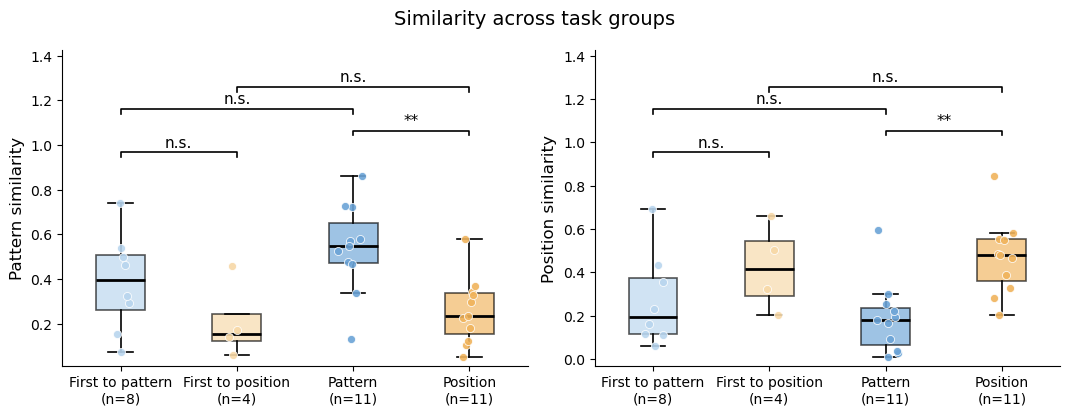

{'df':    mouse_id                                          file_path  \
 0      HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 1      HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 2      HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 3      HP02  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-...   
 4      HP02  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-...   
 5      HP02  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-...   
 6      HP03  ../../../data/HPC_2p/screen/HP03/HP03_2025-01-...   
 7      HP03  ../../../data/HPC_2p/screen/HP03/HP03_2025-01-...   
 8      HP07  ../../../data/HPC_2p/screen/HP07/HP07_2025-03-...   
 9      HP07  ../../../data/HPC_2p/screen/HP07/HP07_2025-03-...   
 10     HP07  ../../../data/HPC_2p/screen/HP07/HP07_2025-03-...   
 11     HP08  ../../../data/HPC_2p/screen/HP08/HP08_2025-03-...   
 12     HP08  ../../../data/HPC_2p/screen/HP08/HP08_2025-03-...   
 13     HP08  ../../../data/HPC_2p/screen/HP08/HP08_2025

In [175]:
run_1()

[Session selection] policy=latest | before=29, after=22
[Multiple sessions detected]
mouse_id task_type reward_mode session_date       session_id                           file_name                                                             file_path
    HP02  position        full   2024-12-22  HP02_2024_12_22 HP02_2024-12-22_position_screen.pkl  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-22_position_screen.pkl
    HP02  position        full   2024-12-23  HP02_2024_12_23 HP02_2024-12-23_position_screen.pkl  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-23_position_screen.pkl
    HP03   pattern        full   2025-01-21  HP03_2025_01_21  HP03_2025-01-21_pattern_screen.pkl   ../../../data/HPC_2p/screen/HP03/HP03_2025-01-21_pattern_screen.pkl
    HP03   pattern        full   2025-01-22  HP03_2025_01_22  HP03_2025-01-22_pattern_screen.pkl   ../../../data/HPC_2p/screen/HP03/HP03_2025-01-22_pattern_screen.pkl
    HP07  position        full   2025-03-04  HP07_2025_03_04 HP07_2025-03-04_pos

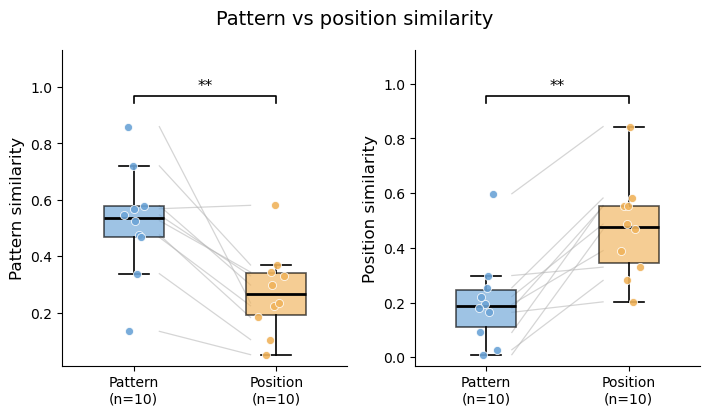

{'df':    mouse_id                                          file_path  \
 0      HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 1      HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 2      HP02  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-...   
 3      HP02  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-...   
 4      HP03  ../../../data/HPC_2p/screen/HP03/HP03_2025-01-...   
 5      HP07  ../../../data/HPC_2p/screen/HP07/HP07_2025-03-...   
 6      HP07  ../../../data/HPC_2p/screen/HP07/HP07_2025-03-...   
 7      HP08  ../../../data/HPC_2p/screen/HP08/HP08_2025-03-...   
 8      HP08  ../../../data/HPC_2p/screen/HP08/HP08_2025-03-...   
 9      HP24  ../../../data/HPC_2p/screen/HP24/HP24_2025-08-...   
 10     HP24  ../../../data/HPC_2p/screen/HP24/HP24_2025-08-...   
 11     HP27  ../../../data/HPC_2p/screen/HP27/HP27_2025-08-...   
 12     HP27  ../../../data/HPC_2p/screen/HP27/HP27_2025-08-...   
 13     HP28  ../../../data/HPC_2p/screen/HP28/HP28_2025

In [176]:
run_2()

[Session selection] policy=latest | before=8, after=8
[OK] HP01 | date=2024-12-13 | group=couple_first_pattern_session | source=first_pattern | ana_tt=couple_ACB,couple_BCA | pattern=0.4201, position=0.2653
[OK] HP03 | date=2025-01-20 | group=couple_first_pattern_session | source=first_pattern | ana_tt=couple_ACB,couple_BCA | pattern=0.5889, position=0.1290
[OK] HP08 | date=2025-03-07 | group=couple_first_pattern_session | source=first_pattern | ana_tt=couple_ACB,couple_BCA | pattern=0.3292, position=0.4284
[OK] HP24 | date=2025-07-30 | group=couple_first_pattern_session | source=first_pattern | ana_tt=couple_ACB,couple_BCA | pattern=0.0411, position=0.9443
[OK] HP27 | date=2025-08-04 | group=couple_first_pattern_session | source=first_pattern | ana_tt=couple_ACB,couple_BCA | pattern=0.0404, position=0.8345
[OK] HP28 | date=2025-08-05 | group=couple_first_pattern_session | source=first_pattern | ana_tt=couple_ACB,couple_BCA | pattern=0.1921, position=0.5667
[OK] HPC13 | date=2025-05-22

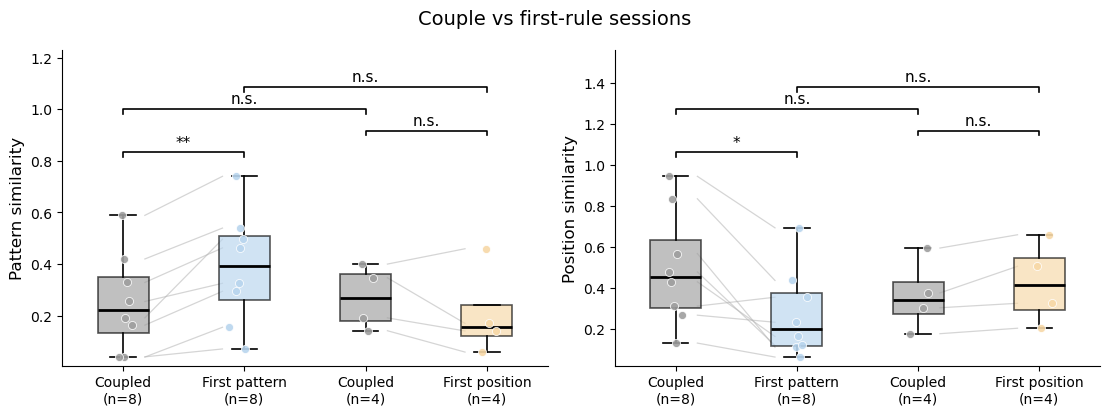

{'df_all':    mouse_id                                          file_path  \
 0      HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 1      HP03  ../../../data/HPC_2p/screen/HP03/HP03_2025-01-...   
 2      HP08  ../../../data/HPC_2p/screen/HP08/HP08_2025-03-...   
 3      HP24  ../../../data/HPC_2p/screen/HP24/HP24_2025-07-...   
 4      HP27  ../../../data/HPC_2p/screen/HP27/HP27_2025-08-...   
 5      HP28  ../../../data/HPC_2p/screen/HP28/HP28_2025-08-...   
 6     HPC13  ../../../data/HPC_2p/screen/HPC13/HPC13_2025-0...   
 7     HPC14  ../../../data/HPC_2p/screen/HPC14/HPC14_2025-0...   
 8      HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 9      HP03  ../../../data/HPC_2p/screen/HP03/HP03_2025-01-...   
 10     HP08  ../../../data/HPC_2p/screen/HP08/HP08_2025-03-...   
 11     HP24  ../../../data/HPC_2p/screen/HP24/HP24_2025-07-...   
 12     HP27  ../../../data/HPC_2p/screen/HP27/HP27_2025-08-...   
 13     HP28  ../../../data/HPC_2p/screen/HP28/HP28_

In [177]:
run_3()

[Session selection] policy=latest | before=12, after=12
[OK] HP01 | date=2024-12-11 | group=couple | source=couple | ana_tt=couple_ACB,couple_BCA | pattern=0.4510, position=0.2941
[OK] HP02 | date=2024-12-20 | group=couple | source=couple | ana_tt=couple_ACB,couple_BCA | pattern=0.4685, position=0.0974
[OK] HP03 | date=2025-01-19 | group=couple | source=couple | ana_tt=couple_ACB,couple_BCA | pattern=0.6817, position=0.0709
[OK] HP07 | date=2025-03-02 | group=couple | source=couple | ana_tt=couple_ACB,couple_BCA | pattern=0.3017, position=0.3929
[OK] HP08 | date=2025-03-06 | group=couple | source=couple | ana_tt=couple_ACB,couple_BCA | pattern=0.3185, position=0.3411
[OK] HP24 | date=2025-07-29 | group=couple | source=couple | ana_tt=couple_ACB,couple_BCA | pattern=0.0291, position=1.0214
[OK] HP27 | date=2025-08-03 | group=couple | source=couple | ana_tt=couple_ACB,couple_BCA | pattern=0.0228, position=1.0478
[OK] HP28 | date=2025-08-04 | group=couple | source=couple | ana_tt=couple_A

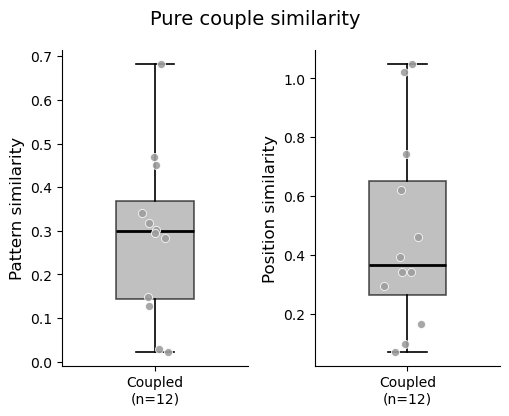

{'df':    mouse_id                                          file_path  \
 0      HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 1      HP02  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-...   
 2      HP03  ../../../data/HPC_2p/screen/HP03/HP03_2025-01-...   
 3      HP07  ../../../data/HPC_2p/screen/HP07/HP07_2025-03-...   
 4      HP08  ../../../data/HPC_2p/screen/HP08/HP08_2025-03-...   
 5      HP24  ../../../data/HPC_2p/screen/HP24/HP24_2025-07-...   
 6      HP27  ../../../data/HPC_2p/screen/HP27/HP27_2025-08-...   
 7      HP28  ../../../data/HPC_2p/screen/HP28/HP28_2025-08-...   
 8      HP29  ../../../data/HPC_2p/screen/HP29/HP29_2025-08-...   
 9      HP31  ../../../data/HPC_2p/screen/HP31/HP31_2025-09-...   
 10    HPC13  ../../../data/HPC_2p/screen/HPC13/HPC13_2025-0...   
 11    HPC14  ../../../data/HPC_2p/screen/HPC14/HPC14_2025-0...   
 
                              file_name suffix file_kind  \
 0    HP01_2024-12-11_couple_screen.pkl   .pkl    pickle   
 

In [178]:
run_4_pure_couple()

In [179]:
def run_1_curve(reward_mode="full"):

    root = "../../../data/HPC_2p/screen/"
    normal_tt = ("ABC", "ACB", "BAC", "BCA", "CAB", "CBA")
    g = lambda name: make_group_name(name, reward_mode)

    df_curve4 = analyze_similarity_files(
        data_root=root,
        task_type=[
            "first_pattern",
            "first_position",
            "pattern",
            "position",
        ],
        reward_mode=reward_mode,
        file_kind="pickle",
        ana_tt=normal_tt,
        ana_bt=("Correct",),
        mode="curve",
        group=None,
        analysis_name="normal_rules_curve",
        group_average="by_trial",
        corr_method="spearman",
        value_type="raw_beta",
        screen_mode="masked",
        session_policy="latest",
        check_unique=True,
        verbose=True,
    )

    group_order = [
        g("first_pattern"),
        g("first_position"),
        g("pattern"),
        g("position"),
    ]

    out_curve4 = plot_similarity_curves(
        df_curve4,
        group_order=group_order,
        test_groups=group_order,
        curve_test=True,
        paired=False,
        p_adjust_method="fdr_bh",
        alpha=0.05,
        error="sem",
        legend="top",
        legend_ncol=4,
        title="Similarity curves across task groups",
        figsize=(10.8, 4.2),
    )

    return {
        "df": df_curve4,
        "out": out_curve4,
    }

In [180]:
def run_2_curve(reward_mode="full"):

    root = "../../../data/HPC_2p/screen/"
    normal_tt = ("ABC", "ACB", "BAC", "BCA", "CAB", "CBA")
    g = lambda name: make_group_name(name, reward_mode)

    df_pattern_position_curve = analyze_similarity_files(
        data_root=root,
        task_type=[
            "pattern",
            "position",
        ],
        reward_mode=reward_mode,
        file_kind="pickle",
        ana_tt=normal_tt,
        ana_bt=("Correct",),
        mode="curve",
        group=None,
        analysis_name="pattern_vs_position_curve",
        group_average="by_trial",
        corr_method="spearman",
        value_type="raw_beta",
        screen_mode="masked",
        session_policy="latest",
        check_unique=True,
        verbose=True,
    )

    # Explicitly drop animals without both pattern and position.
    df_pattern_position_curve_paired = filter_curve_to_common_paired_subjects(
        df_pattern_position_curve,
        groups=(g("pattern"), g("position")),
        value_names=("pattern_value", "position_value"),
        subject_col="mouse_id",
        group_col="group",
        position_col="position_index",
        require_complete_positions=True,
        verbose=True,
    )

    group_order = [
        g("pattern"),
        g("position"),
    ]

    out_pattern_position_curve = plot_similarity_curves(
        df_pattern_position_curve_paired,
        group_order=group_order,
        test_groups=group_order,
        curve_test=True,
        paired=True,
        p_adjust_method="fdr_bh",
        alpha=0.05,
        error="sem",
        legend="top",
        legend_ncol=2,
        title="Pattern vs position paired similarity curves",
        figsize=(10.8, 4.2),
    )

    return {
        "df": df_pattern_position_curve,
        "df_paired": df_pattern_position_curve_paired,
        "out": out_pattern_position_curve,
    }

In [181]:
def run_3_curve(reward_mode="full"):

    root = "../../../data/HPC_2p/screen/"

    normal_tt = ("CAB", "CBA", "ACB", "BCA", "ABC", "BAC")
    couple_tt = ("couple_ACB", "couple_BCA")
    g = lambda name: make_group_name(name, reward_mode)

    df_couple_first_curve = analyze_similarity_files(
        data_root=root,
        reward_mode=reward_mode,
        specs=[
            {
                "task_type": "first_pattern",
                "group": "couple_first_pattern_session",
                "analysis_name": "couple_vs_first_rules_curve",
                "session_policy": "latest",
                "ana_tt": couple_tt,
            },
            {
                "task_type": "first_pattern",
                "group": "first_pattern",
                "analysis_name": "couple_vs_first_rules_curve",
                "session_policy": "latest",
                "ana_tt": normal_tt,
            },
            {
                "task_type": "first_position",
                "group": "couple_first_position_session",
                "analysis_name": "couple_vs_first_rules_curve",
                "session_policy": "latest",
                "ana_tt": couple_tt,
            },
            {
                "task_type": "first_position",
                "group": "first_position",
                "analysis_name": "couple_vs_first_rules_curve",
                "session_policy": "latest",
                "ana_tt": normal_tt,
            },
        ],
        file_kind="pickle",
        ana_bt=("Correct",),
        mode="curve",
        group_average="by_trial",
        corr_method="spearman",
        value_type="raw_beta",
        screen_mode="masked",
        check_unique=True,
        verbose=True,
    )

    # Pairing unit:
    # same mouse + same session date + same source task + same reward mode.
    df_couple_first_curve = df_couple_first_curve.copy()

    df_couple_first_curve["pair_id"] = (
        df_couple_first_curve["mouse_id"].astype(str)
        + "__"
        + df_couple_first_curve["session_date"].astype(str)
        + "__"
        + df_couple_first_curve["source_group"].astype(str)
        + "__"
        + df_couple_first_curve["reward_mode"].astype(str)
    )

    color_map = {
        g("couple_first_pattern_session"): "#9e9e9e",
        g("first_pattern"): "#b8d5ee",
        g("couple_first_position_session"): "#9e9e9e",
        g("first_position"): "#f7d8a6",
    }

    label_map = {
        g("couple_first_pattern_session"): "Couple",
        g("first_pattern"): "First pattern",
        g("couple_first_position_session"): "Couple",
        g("first_position"): "First position",
    }

    # Figure 1:
    # couple block inside first_pattern session
    # vs
    # normal pattern block inside the same session.
    df_first_pattern_curve_paired = filter_curve_to_common_paired_subjects(
        df_couple_first_curve,
        groups=(g("couple_first_pattern_session"), g("first_pattern")),
        value_names=("pattern_value", "position_value"),
        subject_col="pair_id",
        group_col="group",
        position_col="position_index",
        require_complete_positions=True,
        verbose=True,
    )

    out_first_pattern_curve = plot_similarity_curves(
        df_first_pattern_curve_paired,
        group_order=[
            g("couple_first_pattern_session"),
            g("first_pattern"),
        ],
        test_groups=[
            g("couple_first_pattern_session"),
            g("first_pattern"),
        ],
        curve_test=True,
        paired=True,
        p_adjust_method="fdr_bh",
        alpha=0.05,
        error="sem",
        legend="top",
        legend_ncol=2,
        color_map=color_map,
        label_map=label_map,
        title="Couple vs first-pattern session curves",
        figsize=(10.8, 4.2),
    )

    # Figure 2:
    # couple block inside first_position session
    # vs
    # normal position block inside the same session.
    df_first_position_curve_paired = filter_curve_to_common_paired_subjects(
        df_couple_first_curve,
        groups=(g("couple_first_position_session"), g("first_position")),
        value_names=("pattern_value", "position_value"),
        subject_col="pair_id",
        group_col="group",
        position_col="position_index",
        require_complete_positions=True,
        verbose=True,
    )

    out_first_position_curve = plot_similarity_curves(
        df_first_position_curve_paired,
        group_order=[
            g("couple_first_position_session"),
            g("first_position"),
        ],
        test_groups=[
            g("couple_first_position_session"),
            g("first_position"),
        ],
        curve_test=True,
        paired=True,
        p_adjust_method="fdr_bh",
        alpha=0.05,
        error="sem",
        legend="top",
        legend_ncol=2,
        color_map=color_map,
        label_map=label_map,
        title="Couple vs first-position session curves",
        figsize=(10.8, 4.2),
    )

    return {
        "df_all": df_couple_first_curve,
        "df_first_pattern_paired": df_first_pattern_curve_paired,
        "df_first_position_paired": df_first_position_curve_paired,
        "out_first_pattern": out_first_pattern_curve,
        "out_first_position": out_first_position_curve,
    }

[Session selection] policy=latest | before=41, after=34
[Multiple sessions detected]
mouse_id task_type reward_mode session_date       session_id                           file_name                                                             file_path
    HP02  position        full   2024-12-22  HP02_2024_12_22 HP02_2024-12-22_position_screen.pkl  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-22_position_screen.pkl
    HP02  position        full   2024-12-23  HP02_2024_12_23 HP02_2024-12-23_position_screen.pkl  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-23_position_screen.pkl
    HP03   pattern        full   2025-01-21  HP03_2025_01_21  HP03_2025-01-21_pattern_screen.pkl   ../../../data/HPC_2p/screen/HP03/HP03_2025-01-21_pattern_screen.pkl
    HP03   pattern        full   2025-01-22  HP03_2025_01_22  HP03_2025-01-22_pattern_screen.pkl   ../../../data/HPC_2p/screen/HP03/HP03_2025-01-22_pattern_screen.pkl
    HP07  position        full   2025-03-04  HP07_2025_03_04 HP07_2025-03-04_pos

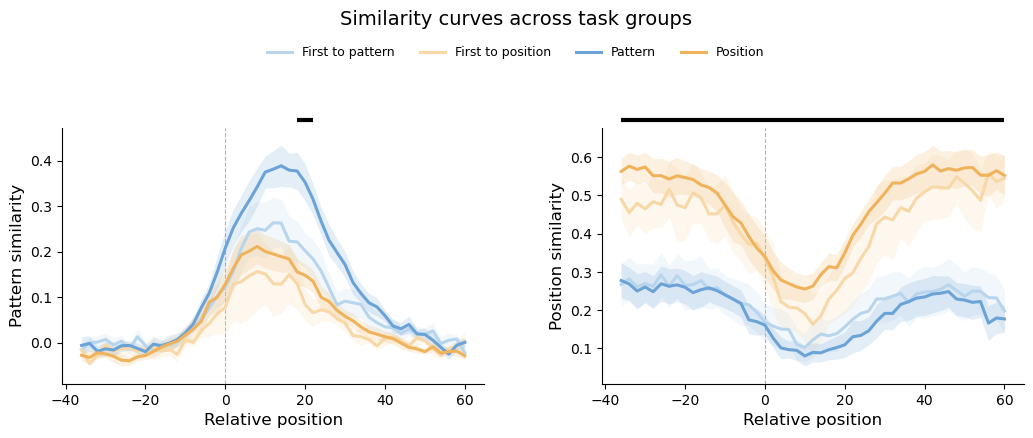

{'df':      mouse_id                                          file_path  \
 0        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 1        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 2        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 3        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 4        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 ...       ...                                                ...   
 1661    HPC14  ../../../data/HPC_2p/screen/HPC14/HPC14_2025-0...   
 1662    HPC14  ../../../data/HPC_2p/screen/HPC14/HPC14_2025-0...   
 1663    HPC14  ../../../data/HPC_2p/screen/HPC14/HPC14_2025-0...   
 1664    HPC14  ../../../data/HPC_2p/screen/HPC14/HPC14_2025-0...   
 1665    HPC14  ../../../data/HPC_2p/screen/HPC14/HPC14_2025-0...   
 
                                      file_name suffix file_kind  \
 0     HP01_2024-12-13_first_pattern_screen.pkl   .pkl    pickle   
 1     HP01_2024-12-13_first

In [182]:
run_1_curve()

[Session selection] policy=latest | before=29, after=22
[Multiple sessions detected]
mouse_id task_type reward_mode session_date       session_id                           file_name                                                             file_path
    HP02  position        full   2024-12-22  HP02_2024_12_22 HP02_2024-12-22_position_screen.pkl  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-22_position_screen.pkl
    HP02  position        full   2024-12-23  HP02_2024_12_23 HP02_2024-12-23_position_screen.pkl  ../../../data/HPC_2p/screen/HP02/HP02_2024-12-23_position_screen.pkl
    HP03   pattern        full   2025-01-21  HP03_2025_01_21  HP03_2025-01-21_pattern_screen.pkl   ../../../data/HPC_2p/screen/HP03/HP03_2025-01-21_pattern_screen.pkl
    HP03   pattern        full   2025-01-22  HP03_2025_01_22  HP03_2025-01-22_pattern_screen.pkl   ../../../data/HPC_2p/screen/HP03/HP03_2025-01-22_pattern_screen.pkl
    HP07  position        full   2025-03-04  HP07_2025_03_04 HP07_2025-03-04_pos

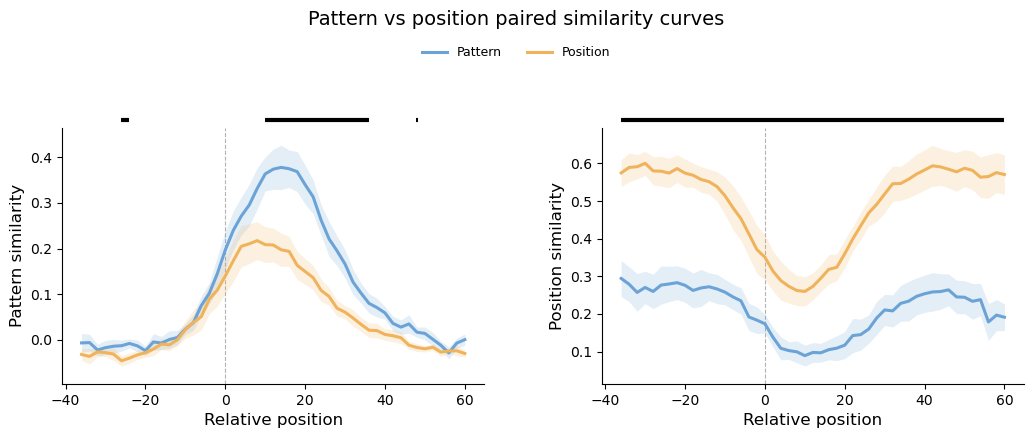

{'df':      mouse_id                                          file_path  \
 0        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 1        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 2        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 3        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 4        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 ...       ...                                                ...   
 1073    HPC14  ../../../data/HPC_2p/screen/HPC14/HPC14_2025-0...   
 1074    HPC14  ../../../data/HPC_2p/screen/HPC14/HPC14_2025-0...   
 1075    HPC14  ../../../data/HPC_2p/screen/HPC14/HPC14_2025-0...   
 1076    HPC14  ../../../data/HPC_2p/screen/HPC14/HPC14_2025-0...   
 1077    HPC14  ../../../data/HPC_2p/screen/HPC14/HPC14_2025-0...   
 
                                  file_name suffix file_kind  \
 0       HP01_2024-12-14_pattern_screen.pkl   .pkl    pickle   
 1       HP01_2024-12-14_pattern_scr

In [183]:
run_2_curve()

[Session selection] policy=latest | before=8, after=8
[OK] HP01 | date=2024-12-13 | group=couple_first_pattern_session | source=first_pattern | ana_tt=couple_ACB,couple_BCA | curve n=49
[OK] HP03 | date=2025-01-20 | group=couple_first_pattern_session | source=first_pattern | ana_tt=couple_ACB,couple_BCA | curve n=49
[OK] HP08 | date=2025-03-07 | group=couple_first_pattern_session | source=first_pattern | ana_tt=couple_ACB,couple_BCA | curve n=49
[OK] HP24 | date=2025-07-30 | group=couple_first_pattern_session | source=first_pattern | ana_tt=couple_ACB,couple_BCA | curve n=49
[OK] HP27 | date=2025-08-04 | group=couple_first_pattern_session | source=first_pattern | ana_tt=couple_ACB,couple_BCA | curve n=49
[OK] HP28 | date=2025-08-05 | group=couple_first_pattern_session | source=first_pattern | ana_tt=couple_ACB,couple_BCA | curve n=49
[OK] HPC13 | date=2025-05-22 | group=couple_first_pattern_session | source=first_pattern | ana_tt=couple_ACB,couple_BCA | curve n=49
[OK] HPC14 | date=202

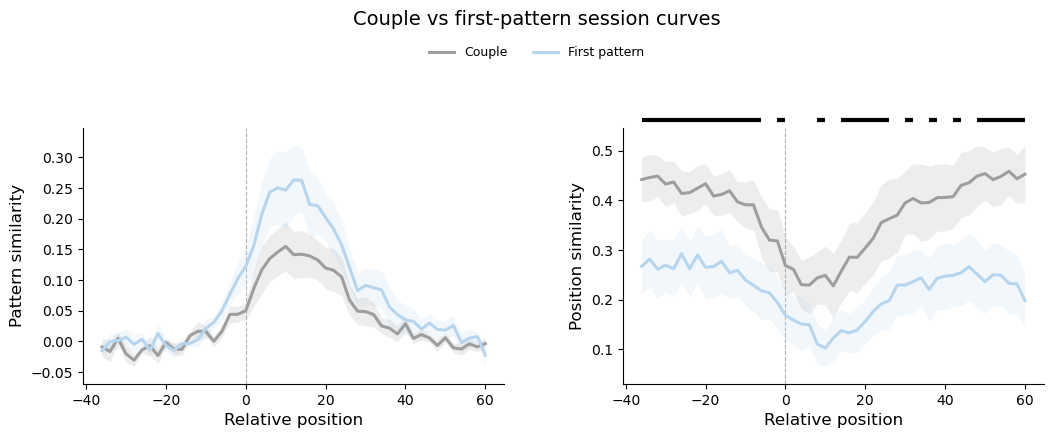

[Curve paired subject filtering]
groups=('couple_first_position_session', 'first_position')
common positions: n=49
couple_first_position_session: n=4
first_position: n=4
common subjects: n=4
excluded only from couple_first_position_session: []
excluded only from first_position: []


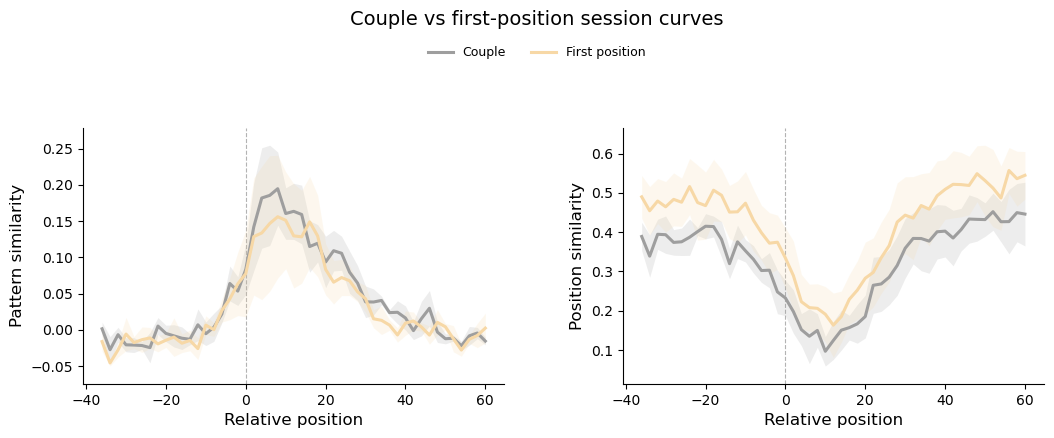

{'df_all':      mouse_id                                          file_path  \
 0        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 1        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 2        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 3        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 4        HP01  ../../../data/HPC_2p/screen/HP01/HP01_2024-12-...   
 ...       ...                                                ...   
 1171     HP31  ../../../data/HPC_2p/screen/HP31/HP31_2025-09-...   
 1172     HP31  ../../../data/HPC_2p/screen/HP31/HP31_2025-09-...   
 1173     HP31  ../../../data/HPC_2p/screen/HP31/HP31_2025-09-...   
 1174     HP31  ../../../data/HPC_2p/screen/HP31/HP31_2025-09-...   
 1175     HP31  ../../../data/HPC_2p/screen/HP31/HP31_2025-09-...   
 
                                       file_name suffix file_kind  \
 0      HP01_2024-12-13_first_pattern_screen.pkl   .pkl    pickle   
 1      HP01_2024-12-1

In [184]:
run_3_curve()